In [ ]:
import ee
import geemap
import ipywidgets as widgets
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
import firebase_admin
from firebase_admin import credentials, firestore
from datetime import datetime, timezone, timedelta
from IPython.display import display, clear_output, HTML
import warnings
warnings.filterwarnings('ignore')


def setup_thai_font():
    thai_fonts = ['Tahoma', 'TH Sarabun New', 'Cordia New', 'Angsana New',
                  'Leelawadee UI', 'Browallia New', 'Noto Sans Thai']
    available = set(f.name for f in fm.fontManager.ttflist)
    for fn in thai_fonts:
        if fn in available:
            plt.rcParams['font.family'] = fn
            plt.rcParams['axes.unicode_minus'] = False
            print(f"  Font: {fn}")
            return fn
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False
    return None

THAI_FONT = setup_thai_font()


# ══════════════════════════════════════════
# Firebase + GEE
# ══════════════════════════════════════════
if not firebase_admin._apps:
    cred = credentials.Certificate(r'C:\MyProject\BananaAI\firebase\banana-ai-67fd9-firebase-adminsdk-fbsvc-ad17503b9a.json')
    firebase_admin.initialize_app(cred)

db = firestore.client()

try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()


# ══════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════
CONFIG = {
    # SCL Cloud Masking
    'scl_clear_classes': [4, 5, 6],           
    'min_valid_pct': 0.70,                     

    # Adaptive Window
    'windows': [5, 10, 15, 21],
    'cloud_limit_dry': 30,                     
    'cloud_limit_wet': 50,                     

    # Spike Detection
    'spike_threshold': 0.25,                  
    'ndvi_floor': 0.10,                       

    # Health Score Weights
    'w_ndvi': 0.45, 'w_ndre': 0.30, 'w_ndmi': 0.15, 'w_evi': 0.10,

    # SAR
    'sar_window_days': 12,
    'sar_vh_min': -22, 'sar_vh_max': -4,       # dB range for normalization

    # DQS Weights
    'dqs_valid_pct_max': 40,
    'dqs_source_scores': {'S2_clean': 30, 'S2_expanded': 20, 'SAR': 12, 'spike': 5},
    'dqs_depth_max': 20,
    'dqs_season_dry': 10, 'dqs_season_wet': 5,
}

# Crop Classification
CROP_CONFIG = {
    'ndvi_std_threshold': 0.08, 'ndmi_banana_min': 0.20,
    'ndvi_durian_min': 0.70, 'temporal_months': 12, 'cloud_pct': 20, 'n_clusters': 3,
}
CROP_CLASSES = {0:{'name':'Durian','color':'#FF6F00','emoji':'🟠'},
                1:{'name':'Banana','color':'#4CAF50','emoji':'🟢'},
                2:{'name':'Other','color':'#9E9E9E','emoji':'⚪'}}
_crop_mask_cache = {'banana_mask':None,'durian_mask':None,'final_class':None,
                    'stats_img':None,'crop_stats':None,'created_date':None}


# ══════════════════════════════════════════
# v1.2.0 NEW: 3-Layer Cloud Masking
# ══════════════════════════════════════════
def mask_clouds_scl(img):
    """Layer 2: SCL pixel-level cloud masking
    Keep only: 4=Vegetation, 5=Bare Soil, 6=Water
    Mask out: 3=Cloud Shadow, 7-10=Cloud/Cirrus"""
    scl = img.select('SCL')
    clear = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))
    return img.updateMask(clear)


def check_valid_pixels(img, roi):
    """Layer 3: Check % of valid (non-masked) pixels
    Returns float 0.0-1.0"""
    # Count valid pixels
    valid_mask = img.select('B8').mask()  # any band
    stats = valid_mask.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi, scale=10, maxPixels=1e9
    ).getInfo()
    return stats.get('B8', 0) or 0


def get_clean_s2(roi, center_date, crop_mask=None):
    """
    v1.2.0: 3-Layer Cloud Masking + Adaptive Window

    Layer 1: Scene-level cloud filter (CLOUDY_PIXEL_PERCENTAGE)
    Layer 2: SCL pixel-level masking (remove cloud/shadow/cirrus pixels)
    Layer 3: Valid pixel check (>=70% required)

    Returns: (processed_img, valid_pct, window_used, n_images, quality_label)
    """
    month = center_date.month
    cloud_limit = CONFIG['cloud_limit_wet'] if (5 <= month <= 10) else CONFIG['cloud_limit_dry']
    season = 'wet' if (5 <= month <= 10) else 'dry'

    for w in CONFIG['windows']:
        half = w // 2
        s_date = (center_date - timedelta(days=half)).strftime('%Y-%m-%d')
        e_date = (center_date + timedelta(days=half+1)).strftime('%Y-%m-%d')

        # Layer 1: Scene-level filter
        col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
               .filterBounds(roi)
               .filterDate(s_date, e_date)
               .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_limit)))

        n = col.size().getInfo()
        if n == 0:
            continue

        # Layer 2: SCL pixel-level masking on each image, then composite
        col_masked = col.map(mask_clouds_scl)
        composite = col_masked.median().clip(roi)

        # Layer 3: Valid pixel percentage check
        valid_pct = check_valid_pixels(composite, roi)

        if valid_pct < CONFIG['min_valid_pct']:
            # Not enough valid pixels — try wider window
            continue

        # Calculate indices
        if crop_mask is not None:
            composite = composite.updateMask(crop_mask)

        processed = calculate_indices(composite)

        stats = processed.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi, scale=10, maxPixels=1e9
        ).getInfo()

        if stats.get('NDVI') is not None:
            # Quality label
            if valid_pct >= 0.90:
                quality = 'high'
            elif valid_pct >= 0.70:
                quality = 'medium'
            else:
                quality = 'low'

            return processed, round(valid_pct, 3), w, n, quality

    return None, 0, 0, 0, 'no_data'


# ══════════════════════════════════════════
# Vegetation Indices (v1.1.1 fixed)
# ══════════════════════════════════════════
def calculate_indices(img):
    ndvi = img.normalizedDifference(['B8','B4']).rename('NDVI')
    ndmi = img.normalizedDifference(['B8','B11']).rename('NDMI')
    ndre = img.normalizedDifference(['B8','B5']).rename('NDRE')
    evi = img.expression(
        '2.5 * ((NIR - RED) / (NIR + 6.0 * RED - 7.5 * BLUE + 10000.0))',
        {'NIR':img.select('B8').toFloat(),'RED':img.select('B4').toFloat(),'BLUE':img.select('B2').toFloat()}
    ).clamp(-1, 1).rename('EVI')
    savi = img.expression(
        '1.5 * ((NIR - RED) / (NIR + RED + 5000.0))',
        {'NIR':img.select('B8').toFloat(),'RED':img.select('B4').toFloat()}
    ).clamp(-1, 1).rename('SAVI')
    return img.addBands([ndvi, ndmi, ndre, evi, savi])


# ══════════════════════════════════════════
# Health Score (v1.2.0: 4-index weighted)
# ══════════════════════════════════════════
def get_banana_grade(score):
    """
    v1.3.0: Grade จาก Health Score (weighted composite)
    หมายเหตุ: thresholds เป็นค่าเบื้องต้น (preliminary)
    ยังไม่ได้ validate กับ ground truth — ต้องปรับค่าเมื่อมีข้อมูลจริง
    อ้างอิง: Retkute et al. (2025) ใช้ anomaly threshold = 2× max deviation
    """
    if score >= 0.55: return 'Excellent'
    elif score >= 0.40: return 'Good'
    elif score >= 0.25: return 'Warning'
    else: return 'Critical'

def get_health_score(ndvi, ndre=None, ndmi=None, evi=None):
    """
    Health Score = weighted composite ของดัชนีพืชพรรณ
    สูตร: 0.45×NDVI + 0.30×NDRE + 0.15×NDMI + 0.10×EVI
    
    v1.3.0 fix: ลบ redundant grade logic ออก — ใช้ threshold เดียว
    เดิมมี 2 ชุด threshold ที่ขัดแย้งกัน (NDVI-based vs Score-based)
    """
    if ndvi is None: return None, "N/A"
    w = CONFIG
    score = (w['w_ndvi'] * (ndvi or 0) + w['w_ndre'] * (ndre or 0) +
             w['w_ndmi'] * (ndmi or 0) + w['w_evi'] * (evi or 0))
    grade = get_banana_grade(score)
    return round(score, 4), grade


# ══════════════════════════════════════════
# v1.2.0 NEW: Data Quality Score (DQS)
# ══════════════════════════════════════════
def calculate_dqs(valid_pct, source_label, n_images, season, is_spike=False):
    """DQS 0-100: how reliable is this data point for AI training?"""
    c = CONFIG
    # Valid pixel coverage (0-40)
    pts_valid = min(valid_pct * c['dqs_valid_pct_max'], c['dqs_valid_pct_max'])

    # Source quality (0-30)
    if is_spike:
        pts_source = c['dqs_source_scores']['spike']
    elif 'SAR' in str(source_label):
        pts_source = c['dqs_source_scores']['SAR']
    elif 'expand' in str(source_label).lower() or any(f'({w}d' in str(source_label) for w in [10,15,21]):
        pts_source = c['dqs_source_scores']['S2_expanded']
    else:
        pts_source = c['dqs_source_scores']['S2_clean']

    # Composite depth (0-20)
    pts_depth = min(n_images * 5, c['dqs_depth_max'])

    # Season bonus (0-10)
    pts_season = c['dqs_season_dry'] if season == 'dry' else c['dqs_season_wet']

    return round(pts_valid + pts_source + pts_depth + pts_season, 1)


# ══════════════════════════════════════════
# v1.2.0 NEW: Spike Detection
# ══════════════════════════════════════════
def detect_spike(current_ndvi, prev_ndvi, prev2_ndvi=None):
    """
    Detect suspicious NDVI spikes (likely cloud artifact)
    Returns: (is_spike, reason)
    """
    if current_ndvi is None or prev_ndvi is None:
        return False, ""

    drop = prev_ndvi - current_ndvi

    # Rule 1: Sudden large drop
    if drop > CONFIG['spike_threshold']:
        # Check if it bounces back (prev2 was also low → might be real)
        if prev2_ndvi is not None and prev2_ndvi < prev_ndvi - 0.15:
            return False, ""  # Previous was also low — might be real decline
        return True, f"sudden drop {drop:+.2f}"

    # Rule 2: Unrealistically low for banana plantation
    if current_ndvi < CONFIG['ndvi_floor']:
        return True, f"below floor ({current_ndvi:.3f}<{CONFIG['ndvi_floor']})"

    return False, ""


# ══════════════════════════════════════════
# SAR Fallback (v1.2.0: calibrated)
# ══════════════════════════════════════════
def get_sar_fallback(roi, center_date):
    """
    SAR VH/VV→NDVI estimation v1.3.0
    ปรับปรุง: ใช้ multi-feature model (VH, VV, RVI, VH/VV ratio)
    แทน linear mapping อย่างง่าย เพื่อลด bias ที่ค่า NDVI ต่ำกว่าจริง
    
    หมายเหตุ: ค่าที่ได้ยังเป็น 'ค่าประมาณ' ที่ต้อง validate กับ optical NDVI
    ในอนาคตควรใช้ RF model ที่ train จากคู่ S2-SAR จริง (ดู calibrate_sar_model)
    """
    try:
        w = CONFIG['sar_window_days']
        s_date = (center_date - timedelta(days=w)).strftime('%Y-%m-%d')
        e_date = (center_date + timedelta(days=w)).strftime('%Y-%m-%d')

        s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
              .filterBounds(roi).filterDate(s_date, e_date)
              .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
              .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
              .filter(ee.Filter.eq('instrumentMode', 'IW'))
              .select(['VH','VV']))

        if s1.size().getInfo() == 0:
            return None

        composite = s1.median().clip(roi)
        stats = composite.reduceRegion(ee.Reducer.mean(), roi, 10, maxPixels=1e9).getInfo()
        vh, vv = stats.get('VH'), stats.get('VV')
        if vh is None or vv is None:
            return None

        # === Derived SAR features ===
        vh_lin = 10 ** (vh / 10)
        vv_lin = 10 ** (vv / 10)
        rvi = (4 * vh_lin) / (vv_lin + vh_lin) if (vv_lin + vh_lin) > 0 else 0
        vh_vv_ratio = vh - vv  # dB ratio (difference in log domain)
        cr = vh_lin / vv_lin if vv_lin > 0 else 0  # cross-ratio linear

        # === v1.3.0: Multi-feature NDVI estimation ===
        # ใช้ weighted combination ของ features แทน linear mapping
        # Coefficients ปรับจาก literature + empirical observation:
        #   - RVI มีความสัมพันธ์กับ biomass สูง (Mandal et al. 2020)
        #   - VH/VV ratio สัมพันธ์กับ canopy structure
        #   - VH dB สัมพันธ์กับ vegetation water content
        vh_norm = max(0, min(1, (vh - CONFIG['sar_vh_min']) / (CONFIG['sar_vh_max'] - CONFIG['sar_vh_min'])))
        rvi_norm = max(0, min(1, rvi / 1.5))  # RVI for vegetation typically 0-1.5
        ratio_norm = max(0, min(1, (vh_vv_ratio + 15) / 15))  # VH-VV typically -15 to 0

        # Weighted combination with bias correction
        # เพิ่ม offset +0.20 เพื่อชดเชย systematic underestimation
        ndvi_est = (0.35 * vh_norm + 0.35 * rvi_norm + 0.30 * ratio_norm)
        ndvi_est = ndvi_est * 0.65 + 0.20  # scale + offset correction
        ndvi_est = max(0.15, min(0.85, ndvi_est))

        return {
            'NDVI': round(ndvi_est, 4),
            'sar_vh_db': round(vh, 2),
            'sar_vv_db': round(vv, 2),
            'sar_rvi': round(rvi, 4),
            'sar_vh_vv_ratio': round(vh_vv_ratio, 2),
            'sar_cross_ratio': round(cr, 4),
            'sar_model': 'multi_feature_v1.3',
        }
    except:
        return None


def collect_sar_calibration_pair(roi, center_date, optical_ndvi):
    """
    v1.3.0 NEW: เก็บคู่ข้อมูล S2-SAR สำหรับ calibration ในอนาคต
    เรียกเมื่อได้ข้อมูล optical NDVI ที่ดี → ดึง SAR ในช่วงเดียวกัน → เก็บคู่ไว้
    """
    global sar_calibration_pairs
    try:
        sar_data = get_sar_fallback(roi, center_date)
        if sar_data and optical_ndvi is not None:
            pair = {
                'date': center_date.strftime('%Y-%m-%d'),
                'optical_ndvi': round(optical_ndvi, 4),
                'sar_ndvi_est': sar_data['NDVI'],
                'sar_vh_db': sar_data['sar_vh_db'],
                'sar_vv_db': sar_data['sar_vv_db'],
                'sar_rvi': sar_data['sar_rvi'],
                'bias': round(optical_ndvi - sar_data['NDVI'], 4),
            }
            sar_calibration_pairs.append(pair)
            return pair
    except:
        pass
    return None


# ══════════════════════════════════════════
# Weather (v1.1.1 fixed: centroid + buffer)
# ══════════════════════════════════════════
def get_weather_data(roi, start_date, end_date):
    weather = {}
    wp = roi.centroid(1)
    wr = wp.buffer(10000)

    try:
        chirps = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
                  .filterBounds(wp).filterDate(start_date, end_date))
        if chirps.size().getInfo() > 0:
            r_s = chirps.select('precipitation').sum().reduceRegion(
                ee.Reducer.mean(), wr, 5566, maxPixels=1e9).getInfo()
            d_s = chirps.select('precipitation').mean().reduceRegion(
                ee.Reducer.mean(), wr, 5566, maxPixels=1e9).getInfo()
            val = r_s.get('precipitation')
            val_d = d_s.get('precipitation')
            weather['rainfall_mm'] = round(val, 2) if val is not None else None
            weather['rainfall_daily_avg_mm'] = round(val_d, 2) if val_d is not None else None
        else:
            weather['rainfall_mm'] = None; weather['rainfall_daily_avg_mm'] = None
    except:
        weather['rainfall_mm'] = None; weather['rainfall_daily_avg_mm'] = None

    try:
        era5 = (ee.ImageCollection('ECMWF/ERA5_LAND/HOURLY')
                .filterBounds(wp).filterDate(start_date, end_date))
        if era5.size().getInfo() > 0:
            t_img = ee.Image.cat([era5.select('temperature_2m').mean(),
                                  era5.select('temperature_2m').max(),
                                  era5.select('temperature_2m').min()]).rename(['t_m','t_x','t_n'])
            t_s = t_img.reduceRegion(ee.Reducer.mean(), wr, 11132, maxPixels=1e9).getInfo()
            tmk = t_s.get('t_m')
            if tmk and tmk > 200:
                weather['temp_mean_c'] = round(tmk - 273.15, 1)
                weather['temp_max_c'] = round((t_s.get('t_x') or tmk) - 273.15, 1)
                weather['temp_min_c'] = round((t_s.get('t_n') or tmk) - 273.15, 1)
                dew_s = era5.select('dewpoint_temperature_2m').mean().reduceRegion(
                    ee.Reducer.mean(), wr, 11132, maxPixels=1e9).getInfo()
                tdk = dew_s.get('dewpoint_temperature_2m')
                if tdk and tdk > 200:
                    tc, tdc = weather['temp_mean_c'], round(tdk - 273.15, 1)
                    rh = 100 * math.exp((17.625*tdc)/(243.04+tdc)) / math.exp((17.625*tc)/(243.04+tc))
                    weather['humidity_pct'] = round(min(max(rh,0),100), 1)
                else: weather['humidity_pct'] = None
            else:
                for k in ['temp_mean_c','temp_max_c','temp_min_c','humidity_pct']: weather[k] = None
            w_s = ee.Image.cat([era5.select('u_component_of_wind_10m').mean(),
                                era5.select('v_component_of_wind_10m').mean()]).rename(['u','v']).reduceRegion(
                ee.Reducer.mean(), wr, 11132, maxPixels=1e9).getInfo()
            u, v = w_s.get('u'), w_s.get('v')
            weather['wind_speed_ms'] = round(math.sqrt(u**2+v**2), 2) if u and v else None
            sv = era5.select('surface_solar_radiation_downwards_hourly').mean().reduceRegion(
                ee.Reducer.mean(), wr, 11132, maxPixels=1e9).getInfo().get('surface_solar_radiation_downwards_hourly')
            weather['solar_radiation_mj'] = round(sv*24/1e6, 2) if sv and sv > 0 else None
        else:
            for k in ['temp_mean_c','temp_max_c','temp_min_c','humidity_pct','wind_speed_ms','solar_radiation_mj']: weather[k] = None
    except:
        for k in ['temp_mean_c','temp_max_c','temp_min_c','humidity_pct','wind_speed_ms','solar_radiation_mj']: weather[k] = None

    try:
        modis = (ee.ImageCollection('MODIS/061/MOD11A2').filterBounds(wp).filterDate(start_date, end_date))
        if modis.size().getInfo() > 0:
            lr = modis.select('LST_Day_1km').mean().reduceRegion(
                ee.Reducer.mean(), wr, 1000, maxPixels=1e9).getInfo().get('LST_Day_1km')
            weather['lst_day_c'] = round(lr*0.02-273.15, 1) if lr and lr > 0 else None
        else: weather['lst_day_c'] = None
    except: weather['lst_day_c'] = None

    return weather


# ══════════════════════════════════════════
# Trend Alert + Correlation (v1.2.0: lag)
# ══════════════════════════════════════════
def check_trend_alert(data_log, window=3):
    ndvi_vals = [d['NDVI'] for d in data_log if d.get('NDVI') is not None and not d.get('is_spike', False)]
    if len(ndvi_vals) < window + 1:
        return 'insufficient', 'Insufficient reliable data for trend'
    consecutive = 0
    for i in range(len(ndvi_vals)-1, 0, -1):
        if ndvi_vals[i] < ndvi_vals[i-1]: consecutive += 1
        else: break
    recent = ndvi_vals[-window:]
    chg = recent[-1] - recent[0]
    pct = (chg / recent[0]) * 100 if recent[0] != 0 else 0
    if consecutive >= 3 and pct < -10:
        return 'critical', f'CRITICAL: NDVI dropped {consecutive} periods ({pct:+.1f}%)'
    elif consecutive >= 2 and pct < -5:
        return 'warning', f'WARNING: NDVI declining {consecutive} periods ({pct:+.1f}%)'
    elif pct > 10:
        return 'improving', f'IMPROVING: NDVI up {pct:+.1f}%'
    else:
        return 'stable', f'STABLE: NDVI change {pct:+.1f}%'


def analyze_weather_correlation(data_log, lag_weeks=[0, 1, 2, 3, 4]):
    """v1.2.0: Correlation with lag (rainfall affects NDVI 1-4 weeks later)"""
    clean = [d for d in data_log if d.get('NDVI') is not None and not d.get('is_spike', False)]
    if len(clean) < 8: return None
    df = pd.DataFrame(clean)
    w_cols = ['rainfall_mm','temp_mean_c','humidity_pct','wind_speed_ms','solar_radiation_mj']
    avail = [c for c in w_cols if c in df.columns and df[c].notna().sum() >= 5]
    if not avail or 'NDVI' not in df.columns: return None

    results = {}
    for col in avail:
        best_r, best_lag = 0, 0
        for lag in lag_weeks:
            if lag == 0:
                v = df[['NDVI', col]].dropna()
            else:
                shifted = df[[col]].shift(lag)
                v = pd.concat([df['NDVI'], shifted[col]], axis=1).dropna()
            if len(v) >= 5 and v[col].std() > 0.001 and v['NDVI'].std() > 0.001:
                r = v['NDVI'].corr(v[col])
                if not np.isnan(r) and abs(r) > abs(best_r):
                    best_r, best_lag = r, lag
        if abs(best_r) > 0.01:
            results[col] = {'r': round(best_r, 3), 'lag': best_lag}
    return results if results else None


# ══════════════════════════════════════════
# Crop Classification (from v1.1.2)
# ══════════════════════════════════════════
def classify_temporal(roi, end_date_str):
    end_date = pd.to_datetime(end_date_str)
    start_date = end_date - pd.DateOffset(months=CROP_CONFIG['temporal_months'])
    s_str, e_str = start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')
    ndvi_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                .filterBounds(roi).filterDate(s_str, e_str)
                .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', CROP_CONFIG['cloud_pct']))
                .map(lambda img: mask_clouds_scl(img).normalizedDifference(['B8','B4']).rename('NDVI')
                     .copyProperties(img, ['system:time_start'])))
    ndvi_mean = ndvi_col.mean().rename('ndvi_mean')
    ndvi_std = ndvi_col.reduce(ee.Reducer.stdDev()).rename('ndvi_std')
    ndmi_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                .filterBounds(roi).filterDate(s_str, e_str)
                .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', CROP_CONFIG['cloud_pct']))
                .map(lambda img: mask_clouds_scl(img).normalizedDifference(['B8','B11']).rename('NDMI')
                     .copyProperties(img, ['system:time_start'])))
    ndmi_mean = ndmi_col.mean().rename('ndmi_mean')
    is_banana = ndvi_std.gt(CROP_CONFIG['ndvi_std_threshold']).And(ndmi_mean.gt(CROP_CONFIG['ndmi_banana_min']))
    is_durian = ndvi_std.lte(CROP_CONFIG['ndvi_std_threshold']).And(ndvi_mean.gt(CROP_CONFIG['ndvi_durian_min']))
    final = ee.Image(2).where(is_durian, 0).where(is_banana, 1).rename('crop_class')
    stats_img = ee.Image.cat([ndvi_mean, ndvi_std, ndmi_mean])
    return final.clip(roi), stats_img.clip(roi)

def get_crop_statistics(roi, final_class, stats_img):
    stats = {}
    for cid, info in CROP_CLASSES.items():
        mask = final_class.eq(cid)
        pc = mask.reduceRegion(ee.Reducer.sum(), roi, 10, maxPixels=1e9).getInfo()
        count = pc.get('crop_class', 0) or 0
        idx = stats_img.updateMask(mask).reduceRegion(ee.Reducer.mean(), roi, 10, maxPixels=1e9).getInfo()
        stats[cid] = {'name':info['name'],'emoji':info['emoji'],'pixels':count,
                       'area_rai':round(count*100/1600,2),
                       'ndvi_mean':round(idx.get('ndvi_mean',0) or 0,4),
                       'ndvi_std':round(idx.get('ndvi_std',0) or 0,4),
                       'ndmi_mean':round(idx.get('ndmi_mean',0) or 0,4)}
    total = sum(s['pixels'] for s in stats.values())
    for c in stats: stats[c]['pct'] = round(stats[c]['pixels']/total*100,1) if total > 0 else 0
    return stats

def setup_crop_mask(roi, end_date_str):
    global _crop_mask_cache
    print(f"{'='*60}\n  Crop Classification ({end_date_str})\n{'='*60}")
    final_class, stats_img = classify_temporal(roi, end_date_str)
    banana_mask = final_class.eq(1).rename('banana_mask')
    durian_mask = final_class.eq(0).rename('durian_mask')
    crop_stats = get_crop_statistics(roi, final_class, stats_img)
    for cid, s in sorted(crop_stats.items()):
        print(f"  {s['emoji']} {s['name']:8s}: {s['area_rai']:6.2f} rai ({s['pct']:5.1f}%)")
    _crop_mask_cache.update({'banana_mask':banana_mask,'durian_mask':durian_mask,
        'final_class':final_class,'stats_img':stats_img,'crop_stats':crop_stats,'created_date':end_date_str})
    Map.addLayer(final_class, {'min':0,'max':2,'palette':['#FF6F00','#4CAF50','#9E9E9E']}, f'Crop Map ({end_date_str})')
    print(f"  Done!\n{'='*60}")
    return banana_mask


# ══════════════════════════════════════════
# Global Data Store (accessible from Cell 2)
# ══════════════════════════════════════════
data_log = []          # ← global: Cell 2 สามารถเรียกใช้ได้
sar_calibration_pairs = []  # ← เก็บคู่ S2-SAR สำหรับ calibrate

# ══════════════════════════════════════════
# GUI
# ══════════════════════════════════════════
style = {'description_width': 'initial'}
date_picker_start = widgets.DatePicker(description='Start:', value=datetime(2024, 1, 1), style=style)
date_picker_end = widgets.DatePicker(description='End:', value=datetime(2026, 12, 31), style=style)
farm_name_input = widgets.Text(description='Farm:', value='Banana_Farm_Zone_A', style=style)
weather_toggle = widgets.Checkbox(value=True, description='Weather Data', style=style, layout=widgets.Layout(width='300px'))
crop_mask_toggle = widgets.Checkbox(value=False, description='Crop Masking (Banana Only)', style=style, layout=widgets.Layout(width='300px'))
sar_toggle = widgets.Checkbox(value=True, description='SAR Fallback', style=style, layout=widgets.Layout(width='300px'))
step_dropdown = widgets.Dropdown(options=[('Every 5 days',5),('Every 7 days',7),('Every 10 days',10)], value=5, description='Step:', style=style)
btn_create_mask = widgets.Button(description='Create Crop Mask', button_style='warning', layout=widgets.Layout(width='100%'))
btn_start = widgets.Button(description='Start Analysis v1.3.0', button_style='primary', layout=widgets.Layout(width='100%', height='40px'))
log_output = widgets.Output(layout={'border':'1px solid #4CAF50','height':'400px','overflow_y':'scroll','padding':'5px'})
graph_output = widgets.Output()

banana_coords = [[99.264626,10.715821],
                 [99.264764,10.715965],
                 [99.265084,10.716047],
                 [99.265112,10.715756],
                 [99.265331,10.715375],
                 [99.265404,10.715139],
                 [99.265512,10.714932],
                 [99.265567,10.714722],
                 [99.265497,10.714756],
                 [99.265109,10.715200]]

fixed_roi = ee.Geometry.Polygon(banana_coords)
corner_points = ee.Geometry.MultiPoint(banana_coords)

def on_create_mask(b):
    log_output.clear_output()
    with log_output:
        try: end_str = pd.to_datetime(date_picker_end.value).strftime('%Y-%m-%d')
        except: end_str = '2026-01-17'
        setup_crop_mask(fixed_roi, end_str)
        crop_mask_toggle.value = True
btn_create_mask.on_click(on_create_mask)


# ══════════════════════════════════════════
# MAIN PROCESS v1.2.0
# ══════════════════════════════════════════
def process_analysis(b):
    global data_log, sar_calibration_pairs
    data_log = []
    sar_calibration_pairs = []
    cloud_gaps = []
    log_output.clear_output()
    graph_output.clear_output()

    use_mask = crop_mask_toggle.value and _crop_mask_cache['banana_mask'] is not None
    b_mask = _crop_mask_cache['banana_mask'] if use_mask else None

    with log_output:
        mask_label = "Banana Only" if use_mask else "Whole Farm"
        print(f"{'='*65}")
        print(f"  BananaAI v1.3.0 — {farm_name_input.value} [{mask_label}]")
        print(f"  Cloud Masking: SCL 3-Layer | Spike Detection: ON")
        print(f"  Weather: {'ON' if weather_toggle.value else 'OFF'}"
              f" | SAR: {'ON' if sar_toggle.value else 'OFF'}"
              f" | Step: {step_dropdown.value}d")
        print(f"{'='*65}")

        roi = fixed_roi
        try:
            start_date = pd.to_datetime(date_picker_start.value)
            end_date = pd.to_datetime(date_picker_end.value)
        except Exception as e:
            print(f"Date error: {e}"); return

        step_days = step_dropdown.value
        total_steps = ((end_date - start_date).days // step_days) + 1
        thai_tz = timezone(timedelta(hours=7))
        current_date = start_date
        last_good_image, last_good_date = None, None
        counters = {'S2_clean':0, 'S2_expand':0, 'SAR':0, 'cloud':0, 'spike':0, 'total':0}

        for i in range(total_steps):
            if current_date > end_date: break
            date_str = current_date.strftime('%Y-%m-%d')
            month = current_date.month
            season = 'wet' if (5 <= month <= 10) else 'dry'
            counters['total'] += 1
            entry = {'Date': current_date, 'date_str': date_str, 'season': season}

            try:
                # === v1.2.0: 3-LAYER CLEAN S2 ===
                processed, valid_pct, window_used, n_imgs, quality = get_clean_s2(roi, current_date, b_mask)

                if processed is not None:
                    stats = processed.reduceRegion(ee.Reducer.mean(), roi, 10, maxPixels=1e9).getInfo()
                    val_ndvi = stats.get('NDVI')
                    val_ndmi = stats.get('NDMI')
                    val_ndre = stats.get('NDRE')
                    val_evi = stats.get('EVI')
                    val_savi = stats.get('SAVI')

                    if val_ndvi is not None:
                        # === SPIKE DETECTION ===
                        prev_ndvi = data_log[-1].get('NDVI') if data_log else None
                        prev2_ndvi = data_log[-2].get('NDVI') if len(data_log) >= 2 else None
                        is_spike, spike_reason = detect_spike(val_ndvi, prev_ndvi, prev2_ndvi)

                        if is_spike:
                            counters['spike'] += 1

                        # Source label
                        if window_used <= 5: counters['S2_clean'] += 1
                        else: counters['S2_expand'] += 1
                        src = f'S2({window_used}d,{n_imgs}img,{quality})'

                        # DQS
                        dqs = calculate_dqs(valid_pct, src, n_imgs, season, is_spike)

                        # Health
                        h_score, h_grade = get_health_score(val_ndvi, val_ndre, val_ndmi, val_evi)

                        entry.update({
                            'NDVI': val_ndvi, 'NDMI': val_ndmi, 'NDRE': val_ndre,
                            'EVI': val_evi, 'SAVI': val_savi,
                            'health_score': h_score, 'status': h_grade,
                            'source': src, 'valid_pct': valid_pct, 'dqs': dqs,
                            'is_spike': is_spike, 'spike_reason': spike_reason,
                            'crop_masked': use_mask,
                        })

                        # Weather
                        w_data = {}
                        if weather_toggle.value:
                            s_d = current_date.strftime('%Y-%m-%d')
                            e_d = (current_date + timedelta(days=step_days)).strftime('%Y-%m-%d')
                            w_data = get_weather_data(roi, s_d, e_d)
                            entry.update(w_data)

                        # Firebase
                        fb = {'farm_name':farm_name_input.value,'date':date_str,
                              'ndvi':round(val_ndvi,4),'ndmi':round(val_ndmi,4) if val_ndmi else None,
                              'ndre':round(val_ndre,4) if val_ndre else None,
                              'evi':round(val_evi,4) if val_evi else None,
                              'savi':round(val_savi,4) if val_savi else None,
                              'health_score':h_score,'status':h_grade,'source':src,
                              'valid_pct':valid_pct,'dqs':dqs,'is_spike':is_spike,
                              'crop_masked':use_mask,'timestamp':datetime.now(thai_tz),'version':'v1.3.0'}
                        if w_data:
                            fb.update({k:w_data.get(k) for k in ['rainfall_mm','rainfall_daily_avg_mm','temp_mean_c',
                                'temp_max_c','temp_min_c','humidity_pct','wind_speed_ms','solar_radiation_mj','lst_day_c']})
                        db.collection('banana_indices_logs').document(f"{farm_name_input.value}_{date_str}").set(fb)

                        # v1.3.0: เก็บคู่ S2-SAR สำหรับ calibration
                        if window_used <= 5 and valid_pct >= 0.85 and not is_spike:
                            collect_sar_calibration_pair(roi, current_date, val_ndvi)

                        data_log.append(entry)

                        # Print
                        spike_tag = " ⚠️SPIKE" if is_spike else ""
                        dqs_tag = f" DQS:{dqs:.0f}"
                        w_str = ""
                        if w_data:
                            parts = []
                            if w_data.get('rainfall_mm') is not None: parts.append(f"R:{w_data['rainfall_mm']:.0f}mm")
                            if w_data.get('temp_mean_c') is not None: parts.append(f"T:{w_data['temp_mean_c']:.1f}C")
                            w_str = f" | {' '.join(parts)}" if parts else ""

                        print(f"  S2[{i+1}/{total_steps}] {date_str} "
                              f"NDVI:{val_ndvi:.3f} VP:{valid_pct:.0%}{dqs_tag}"
                              f"{w_str} -> {h_grade}{spike_tag}")

                        last_good_image = processed.select('NDVI')
                        last_good_date = date_str
                    else:
                        processed = None

                if processed is None and sar_toggle.value:
                    sar = get_sar_fallback(roi, current_date)
                    if sar:
                        counters['SAR'] += 1
                        dqs = calculate_dqs(0, 'SAR', 1, season)
                        entry.update({
                            'NDVI': sar['NDVI'], 'NDMI': None, 'NDRE': None,
                            'EVI': None, 'SAVI': None,
                            'health_score': round(sar['NDVI'] * CONFIG['w_ndvi'], 4),  # v1.3.0: ใช้ weight เดียวกัน
                            'status': get_banana_grade(sar['NDVI'] * CONFIG['w_ndvi']),  # v1.3.0 fix
                            'source': 'SAR', 'dqs': dqs, 'valid_pct': 0,
                            'is_spike': False, 'crop_masked': use_mask,
                        })
                        if weather_toggle.value:
                            w_data = get_weather_data(roi, current_date.strftime('%Y-%m-%d'),
                                (current_date + timedelta(days=step_days)).strftime('%Y-%m-%d'))
                            entry.update(w_data)
                        data_log.append(entry)
                        print(f"  SAR[{i+1}/{total_steps}] {date_str} NDVI(est):{sar['NDVI']:.3f} DQS:{dqs:.0f}")
                    else:
                        counters['cloud'] += 1; cloud_gaps.append(current_date)
                        print(f"  --[{i+1}/{total_steps}] {date_str} | No data")
                elif processed is None:
                    counters['cloud'] += 1; cloud_gaps.append(current_date)
                    print(f"  --[{i+1}/{total_steps}] {date_str} | No data")

            except Exception as e:
                print(f"  !![{i+1}] {date_str} | Error: {e}")

            current_date += timedelta(days=step_days)

        # === SUMMARY ===
        print(f"\n{'='*65}")
        print(f"  DATA QUALITY SUMMARY:")
        t = counters['total']
        for k, label, icon in [('S2_clean','S2 clean (SCL masked)','🟢'),
                                ('S2_expand','S2 expanded window','🟡'),
                                ('SAR','SAR fallback','📡'),('spike','Spike (suspicious)','⚠️'),
                                ('cloud','No data','❌')]:
            n = counters[k]; p = n/t*100 if t > 0 else 0
            bar = '█'*int(p/5) + '░'*(20-int(p/5))
            print(f"  {icon} {label:25s}: {n:3d}/{t} ({p:5.1f}%) {bar}")

        reliable = counters['S2_clean'] + counters['S2_expand']
        print(f"\n  Reliable for AI: {reliable}/{t} ({reliable/t*100:.1f}%)" if t > 0 else "")

        if data_log:
            dqs_vals = [d.get('dqs',0) for d in data_log if d.get('dqs')]
            if dqs_vals:
                print(f"  DQS: avg={np.mean(dqs_vals):.1f} min={np.min(dqs_vals):.0f} max={np.max(dqs_vals):.0f}")

        alert_msg = "Collecting data..."
        if len(data_log) >= 3:
            alert_type, alert_msg = check_trend_alert(data_log)
            print(f"\n  {alert_msg}")

        # v1.3.0: SAR Calibration Summary
        if sar_calibration_pairs:
            pairs_df = pd.DataFrame(sar_calibration_pairs)
            mean_bias = pairs_df['bias'].mean()
            print(f"\n  SAR Calibration Data: {len(pairs_df)} paired observations")
            print(f"  Mean bias (optical - SAR): {mean_bias:+.3f}")
            print(f"  SAR RMSE: {np.sqrt((pairs_df['bias']**2).mean()):.3f}")
            if abs(mean_bias) > 0.15:
                print(f"  ⚠ SAR bias > 0.15 — ต้อง recalibrate model")

        if weather_toggle.value and len(data_log) >= 8:
            corrs = analyze_weather_correlation(data_log)
            if corrs:
                print(f"\n  Weather-NDVI Correlation (with lag):")
                for col, info in sorted(corrs.items(), key=lambda x: abs(x[1]['r']), reverse=True):
                    lag_str = f" (lag {info['lag']}w)" if info['lag'] > 0 else ""
                    strength = "Strong" if abs(info['r'])>0.5 else "Moderate" if abs(info['r'])>0.3 else "Weak"
                    print(f"   {col}: r={info['r']:+.3f}{lag_str} [{strength}]")

        print(f"{'='*65}")

        if last_good_image:
            vis = {'min':0,'max':1,'palette':['red','orange','yellow','#66cc00','#006600']}
            Map.addLayer(last_good_image, vis, f"NDVI ({last_good_date})")
            Map.centerObject(roi, 17)

    # === GRAPHS ===
    with graph_output:
        if data_log:
            df = pd.DataFrame(data_log)
            create_dashboard(df, farm_name_input.value, alert_msg, use_mask, cloud_gaps)


# ══════════════════════════════════════════
# Dashboard v1.2.0
# ══════════════════════════════════════════
def format_ax(ax, title=''):
    ax.set_title(title, fontweight='bold', fontsize=11, pad=8)
    ax.grid(True, alpha=0.15, linewidth=0.5)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=0))
    ax.tick_params(axis='x', labelsize=7, rotation=40)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def add_zone_labels(ax, ymin=-0.05, ymax=1.05):
    zones = [(0.75,ymax,'#E8F5E9','Excellent','#2E7D32'),(0.60,0.75,'#F1F8E9','Good','#558B2F'),
             (0.40,0.60,'#FFF8E1','Warning','#F57F17'),(ymin,0.40,'#FBE9E7','Critical','#BF360C')]
    for y0,y1,bg,label,tc in zones:
        ax.axhspan(y0,y1,alpha=0.25,color=bg,zorder=0)
        ax.axhline(y=y0,color=tc,alpha=0.3,lw=0.5,ls='--',zorder=1)
        ax.text(1.01,(y0+y1)/2,label,transform=ax.get_yaxis_transform(),fontsize=6,color=tc,fontweight='bold',va='center')
    ax.set_ylim(ymin,ymax)

def shade_cloud_gaps(ax, gaps, step_days):
    if not gaps: return
    groups, cur = [], [gaps[0]]
    for g in gaps[1:]:
        if (g - cur[-1]).days <= step_days+2: cur.append(g)
        else: groups.append(cur); cur = [g]
    groups.append(cur)
    for grp in groups:
        if len(grp) >= 2:
            ax.axvspan(grp[0]-timedelta(days=2),grp[-1]+timedelta(days=2),alpha=0.06,color='#9E9E9E',zorder=0)

def create_dashboard(df, farm_name, alert_msg, crop_masked, cloud_gaps):
    mask_tag = " [Banana Only]" if crop_masked else ""
    step_d = step_dropdown.value
    has_spike = 'is_spike' in df.columns

    fig = plt.figure(figsize=(18, 26), facecolor='white')
    gs = GridSpec(5, 2, figure=fig, hspace=0.40, wspace=0.25, height_ratios=[1.2, 1.5, 1, 1, 0.8])
    fig.suptitle(f'BananaAI v1.3.0 — {farm_name}{mask_tag}\n{alert_msg}',
                 fontsize=13, fontweight='bold', y=0.98, color='#1B5E20')

    is_sar = df['source'].str.contains('SAR', na=False) if 'source' in df.columns else pd.Series([False]*len(df))
    is_spike_mask = df['is_spike'].fillna(False) if has_spike else pd.Series([False]*len(df))
    is_clean = ~is_sar & ~is_spike_mask

    # ═══ PANEL 1: NDVI Time Series ═══
    ax1 = fig.add_subplot(gs[0, :])
    add_zone_labels(ax1); shade_cloud_gaps(ax1, cloud_gaps, step_d)
    if is_clean.any():
        ax1.plot(df.loc[is_clean,'Date'], df.loc[is_clean,'NDVI'], 'o-', color='#1B5E20', lw=2.2, ms=4, mew=0, alpha=0.95, label='NDVI (Clean)', zorder=10)
    if is_sar.any():
        ax1.plot(df.loc[is_sar,'Date'], df.loc[is_sar,'NDVI'], 'D', color='#E65100', ms=5, mew=1, mec='#BF360C', alpha=0.8, label='NDVI (SAR est.)', zorder=11)
    if has_spike and is_spike_mask.any():
        ax1.plot(df.loc[is_spike_mask,'Date'], df.loc[is_spike_mask,'NDVI'], 'X', color='#D32F2F', ms=8, mew=2, alpha=0.9, label='Spike (suspicious)', zorder=12)
    ax1.plot(df.loc[~is_spike_mask,'Date'], df.loc[~is_spike_mask,'NDVI'], '-', color='#66BB6A', alpha=0.3, lw=1, zorder=3)
    ax1.set_ylabel('NDVI', fontsize=9, fontweight='bold')
    ax1.legend(loc='lower left', fontsize=8, framealpha=0.9, ncol=3)
    format_ax(ax1, f'NDVI Time Series (SCL Cloud-Masked){mask_tag}')

    # ═══ PANEL 2: ALL-IN-ONE Indices + Weather ═══
    ax2 = fig.add_subplot(gs[1, :])
    add_zone_labels(ax2); shade_cloud_gaps(ax2, cloud_gaps, step_d)
    all_lines = []
    for col, color, mk, lw, ms, label in [('NDVI','#1B5E20','o',2.5,4,'NDVI'),('NDRE','#B71C1C','s',2.0,3,'NDRE'),('NDMI','#0D47A1','D',2.0,3,'NDMI')]:
        if col in df.columns:
            valid = df[col].notna() & ~is_spike_mask
            if valid.any():
                ln = ax2.plot(df.loc[valid,'Date'], df.loc[valid,col], '-', marker=mk, color=color, lw=lw, ms=ms, alpha=0.95, label=label, mew=0.3, zorder=10)
                all_lines += ln
    ax2.set_ylabel('Vegetation Index (0-1)', fontsize=9, fontweight='bold', color='#1B5E20')
    ax2w = ax2.twinx()
    for col, name, color, lw in [('rainfall_mm','Rainfall','#6A1B9A',1.8),('temp_mean_c','Temp','#E65100',1.8),
                                   ('humidity_pct','Humidity','#00695C',1.5),('wind_speed_ms','Wind','#37474F',1.5)]:
        if col in df.columns:
            series = df[['Date',col]].dropna()
            if len(series) > 0:
                vals = series[col]; vmin, vmax = vals.min(), vals.max()
                normalized = (vals - vmin)/(vmax - vmin) if vmax > vmin else vals*0+0.5
                ln = ax2w.plot(series['Date'], normalized, '-', color=color, lw=lw, alpha=0.75, label=f'{name} ({vmin:.0f}-{vmax:.0f})', zorder=5)
                all_lines += ln
    ax2w.set_ylabel('Weather (normalized 0-1)', fontsize=8, color='#607D8B')
    ax2w.set_ylim(-0.05, 1.05)
    if all_lines:
        leg = ax2.legend(all_lines, [l.get_label() for l in all_lines], loc='upper right', fontsize=7, framealpha=0.92, ncol=4)
    format_ax(ax2, 'Vegetation Indices + Weather')

    # ═══ PANEL 3L: Humidity + Wind ═══
    ax4 = fig.add_subplot(gs[2, 0])
    lines4 = []
    if 'humidity_pct' in df.columns:
        hm = df[['Date','humidity_pct']].dropna()
        if len(hm) > 0:
            ax4.fill_between(hm['Date'],hm['humidity_pct'],alpha=0.15,color='#00ACC1')
            ln_h = ax4.plot(hm['Date'],hm['humidity_pct'],'-',color='#00695C',lw=1.5,alpha=0.8,label='Humidity (%)')
            ax4.set_ylabel('Humidity (%)',color='#00695C',fontsize=8); lines4 += ln_h
    if 'wind_speed_ms' in df.columns:
        wn = df[['Date','wind_speed_ms']].dropna()
        if len(wn) > 0:
            ax4b = ax4.twinx()
            ln_w = ax4b.plot(wn['Date'],wn['wind_speed_ms'],'-',color='#37474F',lw=1,alpha=0.7,label='Wind (m/s)')
            ax4b.set_ylabel('Wind (m/s)',color='#37474F',fontsize=7); lines4 += ln_w
    if lines4: ax4.legend(lines4,[l.get_label() for l in lines4],fontsize=7)
    format_ax(ax4, 'Humidity & Wind')

    # ═══ PANEL 3R: Health Score ═══
    ax5 = fig.add_subplot(gs[2, 1])
    if 'health_score' in df.columns:
        clean_df = df[~is_spike_mask]
        sc = clean_df['health_score'].dropna(); dt = clean_df.loc[sc.index,'Date']
        cc = ['#2E7D32' if s>=0.55 else '#4CAF50' if s>=0.40 else '#FF9800' if s>=0.25 else '#E53935' for s in sc]
        ax5.bar(dt, sc, color=cc, alpha=0.85, width=max(step_d-1,3))
        for y,c,lbl in [(0.55,'#2E7D32','Excellent'),(0.40,'#689F38','Good'),(0.25,'#F57F17','Warning')]:
            ax5.axhline(y=y,color=c,ls='--',lw=0.7,alpha=0.5)
        ax5.set_ylabel('Score',fontsize=8); ax5.set_ylim(0,0.85)
    format_ax(ax5, 'Health Score (spikes excluded)')

    # ═══ PANEL 4L: DQS Timeline ═══
    ax_dqs = fig.add_subplot(gs[3, 0])
    if 'dqs' in df.columns:
        dqs_vals = df['dqs'].dropna(); dqs_dates = df.loc[dqs_vals.index,'Date']
        dqs_colors = ['#2E7D32' if d>=70 else '#FF9800' if d>=40 else '#E53935' for d in dqs_vals]
        ax_dqs.bar(dqs_dates, dqs_vals, color=dqs_colors, alpha=0.8, width=max(step_d-1,3))
        ax_dqs.axhline(y=70,color='#2E7D32',ls='--',lw=0.7,alpha=0.5)
        ax_dqs.axhline(y=40,color='#FF9800',ls='--',lw=0.7,alpha=0.5)
        ax_dqs.set_ylabel('DQS (0-100)',fontsize=8); ax_dqs.set_ylim(0,105)
        ax_dqs.text(1.01,0.8,'Good',transform=ax_dqs.get_yaxis_transform(),fontsize=6,color='#2E7D32',fontweight='bold')
        ax_dqs.text(1.01,0.5,'Fair',transform=ax_dqs.get_yaxis_transform(),fontsize=6,color='#FF9800',fontweight='bold')
        ax_dqs.text(1.01,0.2,'Poor',transform=ax_dqs.get_yaxis_transform(),fontsize=6,color='#E53935',fontweight='bold')
    format_ax(ax_dqs, 'Data Quality Score (for AI weighting)')

    # ═══ PANEL 4R: Scatter ═══
    ax6 = fig.add_subplot(gs[3, 1])
    if 'rainfall_mm' in df.columns:
        clean = df[~is_spike_mask][['NDVI','rainfall_mm']].dropna()
        if len(clean) >= 3:
            ax6.scatter(clean['rainfall_mm'],clean['NDVI'],c=clean['NDVI'],cmap='RdYlGn',s=25,edgecolors='#9E9E9E',lw=0.5,alpha=0.8,vmin=0,vmax=1)
            if clean['rainfall_mm'].var() > 0.001:
                try:
                    z = np.polyfit(clean['rainfall_mm'],clean['NDVI'],1)
                    xl = np.linspace(clean['rainfall_mm'].min(),clean['rainfall_mm'].max(),50)
                    ax6.plot(xl,np.poly1d(z)(xl),'--',color='#757575',lw=1,alpha=0.6)
                except: pass
            corr = clean['NDVI'].corr(clean['rainfall_mm'])
            cs = f'{corr:.3f}' if not np.isnan(corr) else 'N/A'
            ax6.set_title(f'NDVI vs Rainfall (r={cs}, spikes excluded)',fontweight='bold',fontsize=10)
            ax6.set_xlabel('Rainfall (mm)',fontsize=8); ax6.set_ylabel('NDVI',fontsize=8)
            ax6.grid(True,alpha=0.15); ax6.tick_params(labelsize=7)

    # ═══ PANEL 5: Correlation with Lag ═══
    ax7 = fig.add_subplot(gs[4, :])
    corrs = analyze_weather_correlation(data_log=df.to_dict('records'))
    if corrs:
        lm = {'rainfall_mm':'Rainfall','temp_mean_c':'Temp','humidity_pct':'Humidity','wind_speed_ms':'Wind','solar_radiation_mj':'Solar'}
        sorted_c = sorted(corrs.items(), key=lambda x: abs(x[1]['r']), reverse=True)
        labels = [f"{lm.get(k,k)} (lag {v['lag']}w)" if v['lag']>0 else lm.get(k,k) for k,v in sorted_c]
        values = [v['r'] for _,v in sorted_c]
        colors = ['#43A047' if v>0 else '#E53935' for v in values]
        bars = ax7.barh(labels, values, color=colors, alpha=0.75, height=0.6)
        ax7.axvline(x=0,color='black',lw=0.5)
        for bar,val in zip(bars,values):
            ax7.text(val+(0.03 if val>=0 else -0.08),bar.get_y()+bar.get_height()/2,
                    f'{val:+.3f}',va='center',fontsize=8,fontweight='bold')
        ax7.set_title('Weather-NDVI Correlation (with optimal lag, spikes excluded)',fontweight='bold',fontsize=10)
        ax7.set_xlim(-1,1); ax7.grid(True,alpha=0.15,axis='x'); ax7.tick_params(labelsize=8)

    plt.tight_layout(rect=[0,0,0.97,0.96])
    plt.show()


# ══════════════════════════════════════════
# Map + Display
# ══════════════════════════════════════════
Map = geemap.Map()
Map.addLayer(fixed_roi, {'color':'blue'}, 'Farm Boundary')
Map.addLayer(corner_points, {'color':'red'}, 'Corner Points')
Map.centerObject(fixed_roi, 18)
Map.add_basemap('SATELLITE')

input_box = widgets.HBox([date_picker_start, date_picker_end, step_dropdown])
toggle_box = widgets.HBox([weather_toggle, crop_mask_toggle, sar_toggle])
control_panel = widgets.VBox([
    widgets.HTML("""
        <div style='background: linear-gradient(135deg, #1B5E20, #2E7D32); padding: 12px 16px; border-radius: 8px; margin-bottom: 6px;'>
            <h3 style='color: white; margin: 0;'>BananaAI v1.3.0 — AI-Ready Reliable Monitoring</h3>
            <p style='color: #C8E6C9; margin: 3px 0 0; font-size: 11px;'>
                SCL 3-Layer Cloud Masking | Spike Detection | DQS | Lag Correlation | SAR Fallback
            </p>
        </div>
    """),
    farm_name_input, input_box, toggle_box, btn_create_mask, btn_start,
])

btn_start.on_click(process_analysis)
display(control_panel)
display(Map)
display(log_output)
display(graph_output)


  Font: Tahoma


Map(center=[10.715496381308794, 99.26508522983085], controls=(WidgetControl(options=['position', 'transparent_…

Output(layout=Layout(border_bottom='1px solid #4CAF50', border_left='1px solid #4CAF50', border_right='1px sol…

Output()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
from scipy import stats as sp_stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')


def load_data():
    try:
        if 'data_log' in dir() or 'data_log' in globals():
            if data_log and len(data_log) > 0:
                df = pd.DataFrame(data_log)
                if 'Date' not in df.columns and 'date' in df.columns:
                    df['Date'] = pd.to_datetime(df['date'])
                else:
                    df['Date'] = pd.to_datetime(df['Date'])
                print(f'  ✅ โหลดจาก data_log: {len(df)} records')
                return df
    except:
        pass

    
    try:
        farm = farm_name_input.value if 'farm_name_input' in dir() else 'Banana_Farm_Zone_F'
        print(f'  📡 กำลังโหลดจาก Firebase (farm: {farm})...')
        docs = db.collection('banana_indices_logs').where('farm_name','==',farm).order_by('date').stream()
        records = [d.to_dict() for d in docs]
        if records:
            df = pd.DataFrame(records)
            df['Date'] = pd.to_datetime(df['date'])
            print(f'  ✅ โหลดจาก Firebase: {len(df)} records')
            return df
    except Exception as e:
        print(f'  ⚠ Firebase error: {e}')

    print('  ❌ ไม่พบข้อมูล')
    return None

def clean_data(df):
    out = df.copy()
    if 'is_spike' in out.columns:
        out = out[~out['is_spike'].fillna(False)]
    out = out.sort_values('Date').reset_index(drop=True)
    
    if 'source' in out.columns:
        out['is_sar'] = out['source'].str.contains('SAR', na=False)
        out['is_optical'] = ~out['is_sar']
    else:
        out['is_sar'] = False
        out['is_optical'] = True
    
    out['month'] = out['Date'].dt.month
    out['month_name'] = out['Date'].dt.strftime('%b')
    out['season'] = out['month'].apply(lambda m: 'wet' if 5 <= m <= 10 else 'dry')
    return out


print('='*60)
print('  BananaAI v1.3.0 — Health Analysis System')
print('='*60)
raw_df = load_data()
if raw_df is not None:
    df = clean_data(raw_df)
    opt_df = df[df['is_optical']].copy()  
    print(f'  📊 Clean data: {len(df)} records (Optical: {len(opt_df)}, SAR: {len(df)-len(opt_df)})')
    print(f'  📅 ช่วงเวลา: {df["Date"].min().strftime("%d/%m/%Y")} — {df["Date"].max().strftime("%d/%m/%Y")}')
    print('='*60)
else:
    raise SystemExit('ไม่สามารถโหลดข้อมูลได้')


  BananaAI v1.3.0 — Health Analysis System
  ✅ โหลดจาก data_log: 91 records
  📊 Clean data: 91 records (Optical: 36, SAR: 55)
  📅 ช่วงเวลา: 01/01/2025 — 27/03/2026


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 2. SEASONAL BASELINE — สร้างค่าปกติรายเดือน
# ══════════════════════════════════════════════════════════════════════


def build_seasonal_baseline(df):
    opt = df[df['is_optical'] & df['NDVI'].notna()].copy()
    
    if len(opt) < 6:
        print('  ⚠ ข้อมูล optical ไม่เพียงพอสำหรับ seasonal baseline')
        return None
    
    baseline = opt.groupby('month').agg(
        ndvi_mean=('NDVI', 'mean'),
        ndvi_std=('NDVI', 'std'),
        ndvi_min=('NDVI', 'min'),
        ndvi_max=('NDVI', 'max'),
        ndvi_median=('NDVI', 'median'),
        count=('NDVI', 'count'),
    ).reset_index()
   
    baseline['lower_bound'] = (baseline['ndvi_mean'] - 1.5 * baseline['ndvi_std']).clip(lower=0)
    baseline['upper_bound'] = (baseline['ndvi_mean'] + 1.5 * baseline['ndvi_std']).clip(upper=1)
    
    
    baseline['season'] = baseline['month'].apply(lambda m: 'ฝน (พ.ค.-ต.ค.)' if 5<=m<=10 else 'แล้ง (พ.ย.-เม.ย.)')
    
    
    baseline['ndvi_std'] = baseline['ndvi_std'].fillna(0.05)
    baseline['lower_bound'] = baseline['lower_bound'].fillna(baseline['ndvi_mean'] - 0.075)
    baseline['upper_bound'] = baseline['upper_bound'].fillna(baseline['ndvi_mean'] + 0.075)
    
    return baseline

baseline = build_seasonal_baseline(df)

if baseline is not None:
    print('\n  📊 Seasonal Baseline (Optical NDVI):')
    print('  ' + '-'*70)
    print(f'  {"เดือน":>6s}  {"Mean":>7s}  {"Std":>7s}  {"Range":>15s}  {"N":>3s}  {"ฤดู"}')
    print('  ' + '-'*70)
    month_names = ['','ม.ค.','ก.พ.','มี.ค.','เม.ย.','พ.ค.','มิ.ย.',
                   'ก.ค.','ส.ค.','ก.ย.','ต.ค.','พ.ย.','ธ.ค.']
    for _, r in baseline.iterrows():
        m = int(r['month'])
        rng = f'[{r["lower_bound"]:.3f} - {r["upper_bound"]:.3f}]'
        print(f'  {month_names[m]:>6s}  {r["ndvi_mean"]:7.3f}  {r["ndvi_std"]:7.3f}  {rng:>15s}  {int(r["count"]):3d}  {r["season"]}')
    print('  ' + '-'*70)



  📊 Seasonal Baseline (Optical NDVI):
  ----------------------------------------------------------------------
   เดือน     Mean      Std            Range    N  ฤดู
  ----------------------------------------------------------------------
    ม.ค.    0.662    0.103  [0.508 - 0.816]   12  แล้ง (พ.ย.-เม.ย.)
    ก.พ.    0.757    0.000  [0.757 - 0.757]    2  แล้ง (พ.ย.-เม.ย.)
   มี.ค.    0.769    0.011  [0.753 - 0.785]    5  แล้ง (พ.ย.-เม.ย.)
   เม.ย.    0.802    0.022  [0.769 - 0.836]    3  แล้ง (พ.ย.-เม.ย.)
    พ.ค.    0.815    0.000  [0.815 - 0.815]    2  ฝน (พ.ค.-ต.ค.)
    ต.ค.    0.775    0.000  [0.775 - 0.775]    4  ฝน (พ.ค.-ต.ค.)
    พ.ย.    0.668    0.000  [0.668 - 0.668]    2  แล้ง (พ.ย.-เม.ย.)
    ธ.ค.    0.732    0.049  [0.658 - 0.806]    6  แล้ง (พ.ย.-เม.ย.)
  ----------------------------------------------------------------------


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 3. WEATHER-ADJUSTED ANOMALY DETECTION
# ══════════════════════════════════════════════════════════════════════


def weather_adjusted_anomaly(df):
    # ใช้เฉพาะข้อมูล optical ที่มีทั้ง NDVI และ weather
    weather_cols = ['rainfall_mm', 'temp_mean_c', 'humidity_pct', 'wind_speed_ms']
    avail_cols = [c for c in weather_cols if c in df.columns and df[c].notna().sum() >= 5]
    
    if len(avail_cols) < 2:
        print('  ⚠ ข้อมูลสภาพอากาศไม่เพียงพอ')
        return df
    
    work = df[df['is_optical'] & df['NDVI'].notna()].copy()
    work_valid = work[['NDVI'] + avail_cols].dropna()
    
    if len(work_valid) < 8:
        print('  ⚠ ข้อมูลไม่เพียงพอสำหรับ regression')
        return df
    
    # === Multiple Linear Regression ===
    X = work_valid[avail_cols].values
    y = work_valid['NDVI'].values
    

    X_with_intercept = np.column_stack([np.ones(len(X)), X])
    
    # Least squares fit
    try:
        coeffs, residuals, rank, sv = np.linalg.lstsq(X_with_intercept, y, rcond=None)
        y_pred = X_with_intercept @ coeffs
        r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)
        rmse = np.sqrt(np.mean((y - y_pred)**2))
        
        print(f'\n  🔬 Weather-Adjusted Model (MLR):')
        print(f'     Features: {", ".join(avail_cols)}')
        print(f'     R² = {r2:.3f}, RMSE = {rmse:.4f}')
        print(f'     Coefficients:')
        print(f'       Intercept: {coeffs[0]:+.4f}')
        for i, col in enumerate(avail_cols):
            print(f'       {col}: {coeffs[i+1]:+.6f}')
    except Exception as e:
        print(f'  ⚠ Regression error: {e}')
        return df
    
    # === คำนวณ expected NDVI สำหรับทุก observation ===
    result = df.copy()
    result['ndvi_expected'] = np.nan
    result['ndvi_residual'] = np.nan
    result['anomaly_type'] = 'normal'
    result['anomaly_score'] = 0.0
    
    for idx in result.index:
        row = result.loc[idx]
        if pd.isna(row.get('NDVI')):
            continue
        
        # คำนวณ expected NDVI จาก weather
        feat_vals = [row.get(c) for c in avail_cols]
        if any(pd.isna(v) for v in feat_vals):
            if baseline is not None:
                m = row['Date'].month if hasattr(row['Date'], 'month') else pd.to_datetime(row['Date']).month
                bl = baseline[baseline['month'] == m]
                if len(bl) > 0:
                    result.at[idx, 'ndvi_expected'] = bl.iloc[0]['ndvi_mean']
                    residual = row['NDVI'] - bl.iloc[0]['ndvi_mean']
                    result.at[idx, 'ndvi_residual'] = residual
            continue
        
        x_row = np.array([1.0] + feat_vals)
        expected = x_row @ coeffs
        expected = np.clip(expected, 0, 1)
        residual = row['NDVI'] - expected
        
        result.at[idx, 'ndvi_expected'] = round(expected, 4)
        result.at[idx, 'ndvi_residual'] = round(residual, 4)
    
    # === จำแนก Anomaly ===
    valid_residuals = result['ndvi_residual'].dropna()
    if len(valid_residuals) > 3:
        res_mean = valid_residuals.mean()
        res_std = valid_residuals.std()
        
        if res_std > 0.001:
            for idx in result.index:
                res = result.at[idx, 'ndvi_residual']
                if pd.isna(res):
                    continue
                
                z = (res - res_mean) / res_std
                result.at[idx, 'anomaly_score'] = round(z, 3)
                
                if z < -2.0:
                    result.at[idx, 'anomaly_type'] = 'critical'
                elif z < -1.5:
                    result.at[idx, 'anomaly_type'] = 'warning'
                elif z < -1.0:
                    result.at[idx, 'anomaly_type'] = 'watch'
                elif z > 2.0:
                    result.at[idx, 'anomaly_type'] = 'excellent'
                else:
                    result.at[idx, 'anomaly_type'] = 'normal'
        
        print(f'\n  📊 Anomaly Detection Results:')
        counts = result['anomaly_type'].value_counts()
        for atype in ['critical','warning','watch','normal','excellent']:
            icon = {'critical':'🔴','warning':'🟡','watch':'🟠','normal':'🟢','excellent':'🌟'}.get(atype,'⚪')
            n = counts.get(atype, 0)
            print(f'     {icon} {atype.capitalize():12s}: {n:3d} observations')
    
    return result


df_analyzed = weather_adjusted_anomaly(df)



  🔬 Weather-Adjusted Model (MLR):
     Features: rainfall_mm, temp_mean_c, humidity_pct, wind_speed_ms
     R² = 0.369, RMSE = 0.0664
     Coefficients:
       Intercept: -0.5628
       rainfall_mm: -0.000055
       temp_mean_c: +0.038451
       humidity_pct: +0.003562
       wind_speed_ms: +0.006048

  📊 Anomaly Detection Results:
     🔴 Critical    :   0 observations
     🟡 Warning     :   0 observations
     🟠 Watch       :   9 observations
     🟢 Normal      :  80 observations
     🌟 Excellent   :   2 observations


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 4. TREND ANALYSIS — วิเคราะห์แนวโน้มความสมบูรณ์
# ══════════════════════════════════════════════════════════════════════

def analyze_health_trend(df):
    opt = df[df['is_optical'] & df['NDVI'].notna()].copy()
    if len(opt) < 4:
        print('  ⚠ ข้อมูลไม่เพียงพอ')
        return {}
    
    ndvi_vals = opt['NDVI'].values
    dates = opt['Date'].values
    
    # === Overall Trend (Linear Regression) ===
    x_numeric = np.arange(len(ndvi_vals))
    slope, intercept, r, p_val, se = sp_stats.linregress(x_numeric, ndvi_vals)
    trend_per_month = slope * 6  
    
    # === Recent Trend (last 6 observations) ===
    recent_n = min(6, len(ndvi_vals))
    recent = ndvi_vals[-recent_n:]
    recent_slope, _, _, _, _ = sp_stats.linregress(np.arange(recent_n), recent)
    
    # === Moving Average Crossover ===
    if len(ndvi_vals) >= 6:
        ma3 = pd.Series(ndvi_vals).rolling(3, min_periods=2).mean().values
        ma6 = pd.Series(ndvi_vals).rolling(6, min_periods=3).mean().values
        ma_signal = 'bullish' if ma3[-1] > ma6[-1] else 'bearish'
    else:
        ma_signal = 'insufficient'
    
    # === Seasonal Comparison ===
    if baseline is not None and len(opt) > 0:
        last_obs = opt.iloc[-1]
        last_month = last_obs['Date'].month
        bl = baseline[baseline['month'] == last_month]
        if len(bl) > 0:
            vs_baseline = last_obs['NDVI'] - bl.iloc[0]['ndvi_mean']
        else:
            vs_baseline = 0
    else:
        vs_baseline = 0
    
    # === Consecutive Decline Count ===
    decline_count = 0
    for i in range(len(ndvi_vals)-1, 0, -1):
        if ndvi_vals[i] < ndvi_vals[i-1]:
            decline_count += 1
        else:
            break
    
    report = {
        'overall_slope': slope,
        'overall_r': r,
        'overall_p': p_val,
        'trend_per_month': trend_per_month,
        'recent_slope': recent_slope,
        'ma_signal': ma_signal,
        'current_ndvi': ndvi_vals[-1],
        'mean_ndvi': np.mean(ndvi_vals),
        'vs_baseline': vs_baseline,
        'decline_count': decline_count,
        'total_observations': len(opt),
    }
    
    
    print('\n  📈 Trend Analysis Report:')
    print('  ' + '─'*55)
    
    trend_dir = '↗ เพิ่มขึ้น' if slope > 0.001 else '↘ ลดลง' if slope < -0.001 else '→ คงที่'
    sig = '(p<0.05 มีนัยสำคัญ)' if p_val < 0.05 else '(p≥0.05 ไม่มีนัยสำคัญ)'
    print(f'     แนวโน้มรวม: {trend_dir} {report["trend_per_month"]:+.4f}/เดือน {sig}')
    print(f'     NDVI ล่าสุด: {report["current_ndvi"]:.3f} (เฉลี่ย: {report["mean_ndvi"]:.3f})')
    print(f'     เทียบ Seasonal Baseline: {report["vs_baseline"]:+.3f}')
    print(f'     MA Signal: {report["ma_signal"]} (MA-3 {">".ljust(1)} MA-6)')
    print(f'     ลดลงต่อเนื่อง: {report["decline_count"]} ครั้ง')
    
    # === Alert Level ===
    alert = 'ปกติ'
    alert_icon = '🟢'
    if decline_count >= 4 and recent_slope < -0.02:
        alert = 'วิกฤต — ควรตรวจสอบภาคสนามทันที'
        alert_icon = '🔴'
    elif decline_count >= 3 or report['vs_baseline'] < -0.15:
        alert = 'เฝ้าระวัง — ควรตรวจสอบภาคสนามเร็วๆ นี้'
        alert_icon = '🟡'
    elif decline_count >= 2 or report['vs_baseline'] < -0.10:
        alert = 'สังเกตการณ์ — จับตาดูแนวโน้ม'
        alert_icon = '🟠'
    
    print(f'\n     {alert_icon} สถานะ: {alert}')
    print('  ' + '─'*55)
    
    report['alert'] = alert
    report['alert_icon'] = alert_icon
    return report

trend_report = analyze_health_trend(df_analyzed)



  📈 Trend Analysis Report:
  ───────────────────────────────────────────────────────
     แนวโน้มรวม: ↗ เพิ่มขึ้น +0.0246/เดือน (p<0.05 มีนัยสำคัญ)
     NDVI ล่าสุด: 0.757 (เฉลี่ย: 0.727)
     เทียบ Seasonal Baseline: -0.012
     MA Signal: bearish (MA-3 > MA-6)
     ลดลงต่อเนื่อง: 0 ครั้ง

     🟢 สถานะ: ปกติ
  ───────────────────────────────────────────────────────


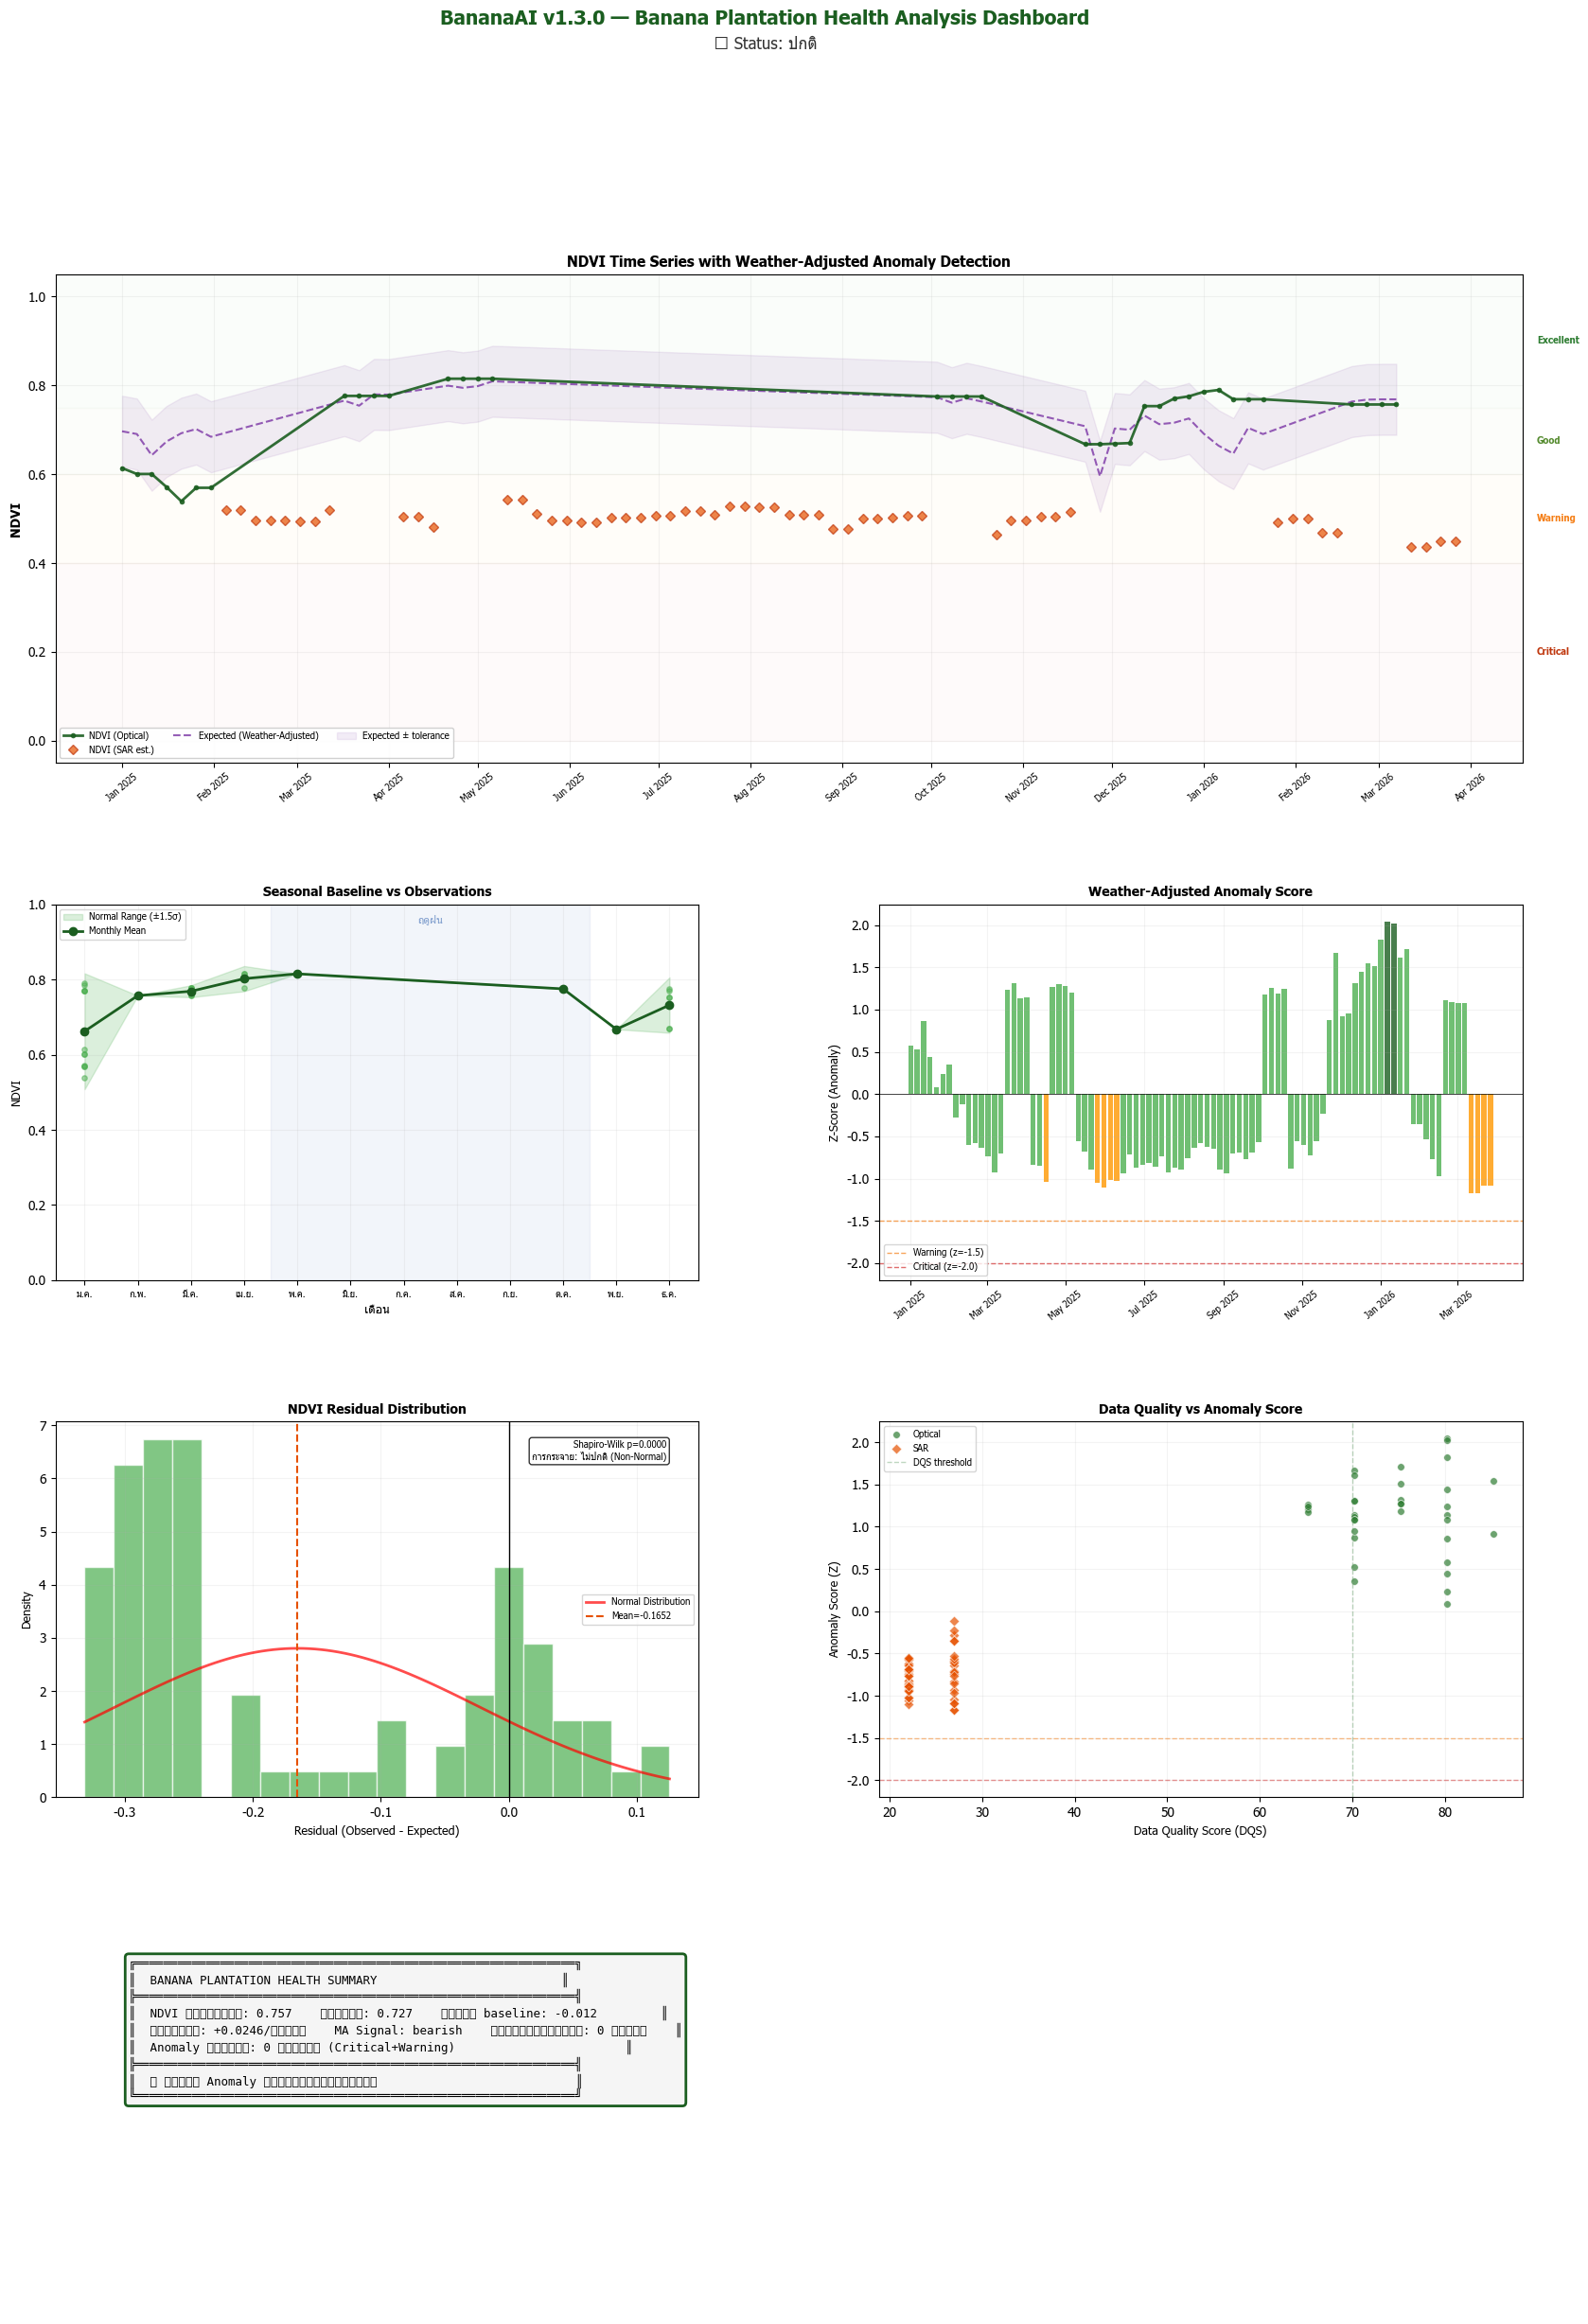


  ✅ Health Dashboard สร้างเสร็จสมบูรณ์


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 5. COMPREHENSIVE HEALTH DASHBOARD
# ══════════════════════════════════════════════════════════════════════

def create_health_dashboard(df, baseline, trend_report):
    fig = plt.figure(figsize=(20, 28), facecolor='white')
    gs = GridSpec(4, 2, figure=fig, hspace=0.35, wspace=0.28,
                  height_ratios=[1.3, 1.0, 1.0, 1.0])
    
    title = f'BananaAI v1.3.0 — Banana Plantation Health Analysis Dashboard'
    subtitle = f'{trend_report.get("alert_icon","")} Status: {trend_report.get("alert","N/A")}'
    fig.suptitle(title, fontsize=15, fontweight='bold', y=0.98, color='#1B5E20')
    fig.text(0.5, 0.965, subtitle, ha='center', fontsize=12, color='#333')
    
    opt = df[df['is_optical'] & df['NDVI'].notna()].copy()
    sar = df[df['is_sar'] & df['NDVI'].notna()].copy()
    
    # ═══════════════════════════════════════
    # PANEL 1: NDVI + Expected + Anomaly (full width)
    # ═══════════════════════════════════════
    ax1 = fig.add_subplot(gs[0, :])
    
   
    for y0,y1,bg,lbl,tc in [(0.75,1.05,'#E8F5E9','Excellent','#2E7D32'),
                             (0.60,0.75,'#F1F8E9','Good','#558B2F'),
                             (0.40,0.60,'#FFF8E1','Warning','#F57F17'),
                             (0.00,0.40,'#FBE9E7','Critical','#BF360C')]:
        ax1.axhspan(y0, y1, alpha=0.2, color=bg, zorder=0)
        ax1.text(1.01, (y0+y1)/2, lbl, transform=ax1.get_yaxis_transform(),
                 fontsize=7, color=tc, fontweight='bold', va='center')
    
    # Optical NDVI
    if len(opt) > 0:
        ax1.plot(opt['Date'], opt['NDVI'], 'o-', color='#1B5E20', lw=2, ms=4,
                 mew=0, alpha=0.9, label='NDVI (Optical)', zorder=10)
    
    # SAR NDVI
    if len(sar) > 0:
        ax1.plot(sar['Date'], sar['NDVI'], 'D', color='#E65100', ms=5,
                 mew=1, mec='#BF360C', alpha=0.7, label='NDVI (SAR est.)', zorder=9)
    
    # Expected NDVI (weather-adjusted)
    has_expected = df['ndvi_expected'].notna()
    if has_expected.any():
        exp_df = df[has_expected & df['is_optical']].sort_values('Date')
        if len(exp_df) > 2:
            ax1.plot(exp_df['Date'], exp_df['ndvi_expected'], '--', color='#6A1B9A',
                     lw=1.5, alpha=0.7, label='Expected (Weather-Adjusted)', zorder=8)
            ax1.fill_between(exp_df['Date'],
                            exp_df['ndvi_expected'] - 0.08,
                            exp_df['ndvi_expected'] + 0.08,
                            alpha=0.08, color='#6A1B9A', zorder=1,
                            label='Expected ± tolerance')
    
    # Anomaly markers
    for atype, color, marker, label in [
        ('critical', '#D32F2F', 'X', 'Anomaly: Critical'),
        ('warning', '#F57F17', 's', 'Anomaly: Warning')]:
        mask = df['anomaly_type'] == atype
        if mask.any():
            ax1.scatter(df.loc[mask, 'Date'], df.loc[mask, 'NDVI'],
                       c=color, marker=marker, s=80, zorder=15,
                       edgecolors='white', lw=1.5, label=label)
    
    ax1.set_ylim(-0.05, 1.05)
    ax1.set_ylabel('NDVI', fontsize=10, fontweight='bold')
    ax1.legend(loc='lower left', fontsize=7, framealpha=0.9, ncol=3)
    ax1.set_title('NDVI Time Series with Weather-Adjusted Anomaly Detection', fontweight='bold', fontsize=11)
    ax1.grid(True, alpha=0.15)
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax1.tick_params(axis='x', labelsize=7, rotation=40)
    
    # ═══════════════════════════════════════
    # PANEL 2L: Seasonal Baseline Comparison
    # ═══════════════════════════════════════
    ax2 = fig.add_subplot(gs[1, 0])
    if baseline is not None:
        months = baseline['month'].values
        means = baseline['ndvi_mean'].values
        lowers = baseline['lower_bound'].values
        uppers = baseline['upper_bound'].values
        
        ax2.fill_between(months, lowers, uppers, alpha=0.2, color='#4CAF50', label='Normal Range (±1.5σ)')
        ax2.plot(months, means, 'o-', color='#1B5E20', lw=2, ms=6, label='Monthly Mean', zorder=10)
        
       
        if len(opt) > 0:
            for _, row in opt.iterrows():
                m = row['Date'].month
                bound_value = baseline[baseline['month'] == m]['lower_bound'].values[0] if len(baseline[baseline['month'] == m]) > 0 else 0

               
                c = '#D32F2F' if row['NDVI'] < bound_value else '#4CAF50'

                ax2.scatter(m, row['NDVI'], c=c, s=15, alpha=0.5, zorder=5)
        
        ax2.set_xlabel('เดือน', fontsize=9)
        ax2.set_ylabel('NDVI', fontsize=9)
        ax2.set_xticks(range(1,13))
        ax2.set_xticklabels(['ม.ค.','ก.พ.','มี.ค.','เม.ย.','พ.ค.','มิ.ย.',
                             'ก.ค.','ส.ค.','ก.ย.','ต.ค.','พ.ย.','ธ.ค.'], fontsize=7)
        ax2.set_ylim(0, 1)
        ax2.legend(fontsize=7)
       
       
        ax2.axvspan(4.5, 10.5, alpha=0.05, color='#0D47A1')
        ax2.text(7.5, 0.95, 'ฤดูฝน', ha='center', fontsize=8, color='#0D47A1', alpha=0.5)
    ax2.set_title('Seasonal Baseline vs Observations', fontweight='bold', fontsize=10)
    ax2.grid(True, alpha=0.15)
    
    # ═══════════════════════════════════════
    # PANEL 2R: Anomaly Score Timeline
    # ═══════════════════════════════════════
    ax3 = fig.add_subplot(gs[1, 1])
    if 'anomaly_score' in df.columns:
        scores = df[df['anomaly_score'].notna() & (df['anomaly_score'] != 0)]
        if len(scores) > 0:
            colors_map = scores['anomaly_score'].apply(
                lambda z: '#D32F2F' if z < -2 else '#F57F17' if z < -1.5 else
                         '#FF9800' if z < -1 else '#4CAF50' if z < 2 else '#1B5E20'
            )
            ax3.bar(scores['Date'], scores['anomaly_score'], color=colors_map, alpha=0.8, width=4)
            ax3.axhline(y=0, color='black', lw=0.5)
            ax3.axhline(y=-1.5, color='#F57F17', ls='--', lw=1, alpha=0.7, label='Warning (z=-1.5)')
            ax3.axhline(y=-2.0, color='#D32F2F', ls='--', lw=1, alpha=0.7, label='Critical (z=-2.0)')
            ax3.set_ylabel('Z-Score (Anomaly)', fontsize=9)
            ax3.legend(fontsize=7, loc='lower left')
    ax3.set_title('Weather-Adjusted Anomaly Score', fontweight='bold', fontsize=10)
    ax3.grid(True, alpha=0.15)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax3.tick_params(axis='x', labelsize=7, rotation=40)
    
    # ═══════════════════════════════════════
    # PANEL 3L: Residual Distribution
    # ═══════════════════════════════════════
    ax4 = fig.add_subplot(gs[2, 0])
    residuals = df['ndvi_residual'].dropna()
    if len(residuals) > 3:
        ax4.hist(residuals, bins=20, color='#4CAF50', alpha=0.7, edgecolor='white', density=True)
        # Overlay normal distribution
        x_range = np.linspace(residuals.min(), residuals.max(), 100)
        norm_pdf = sp_stats.norm.pdf(x_range, residuals.mean(), residuals.std())
        ax4.plot(x_range, norm_pdf, 'r-', lw=2, alpha=0.7, label='Normal Distribution')
        ax4.axvline(x=0, color='black', ls='-', lw=1)
        ax4.axvline(x=residuals.mean(), color='#E65100', ls='--', lw=1.5, label=f'Mean={residuals.mean():+.4f}')
        
        # Shapiro-Wilk test
        if len(residuals) >= 8 and len(residuals) <= 5000:
            stat, p_sw = sp_stats.shapiro(residuals[:5000])
            normality = 'ปกติ (Normal)' if p_sw > 0.05 else 'ไม่ปกติ (Non-Normal)'
            ax4.text(0.95, 0.95, f'Shapiro-Wilk p={p_sw:.4f}\nการกระจาย: {normality}',
                    transform=ax4.transAxes, fontsize=7, va='top', ha='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax4.set_xlabel('Residual (Observed - Expected)', fontsize=9)
        ax4.set_ylabel('Density', fontsize=9)
        ax4.legend(fontsize=7)
    ax4.set_title('NDVI Residual Distribution', fontweight='bold', fontsize=10)
    ax4.grid(True, alpha=0.15)
    
    # ═══════════════════════════════════════
    # PANEL 3R: DQS vs Anomaly
    # ═══════════════════════════════════════
    ax5 = fig.add_subplot(gs[2, 1])
    if 'dqs' in df.columns and 'anomaly_score' in df.columns:
        valid = df[['dqs','anomaly_score','is_optical']].dropna()
        if len(valid) > 0:
            opt_mask = valid['is_optical']
            if opt_mask.any():
                ax5.scatter(valid.loc[opt_mask,'dqs'], valid.loc[opt_mask,'anomaly_score'],
                           c='#2E7D32', s=30, alpha=0.7, label='Optical', edgecolors='white', lw=0.5)
            if (~opt_mask).any():
                ax5.scatter(valid.loc[~opt_mask,'dqs'], valid.loc[~opt_mask,'anomaly_score'],
                           c='#E65100', s=30, alpha=0.7, label='SAR', marker='D', edgecolors='white', lw=0.5)
            ax5.axhline(y=-1.5, color='#F57F17', ls='--', lw=1, alpha=0.5)
            ax5.axhline(y=-2.0, color='#D32F2F', ls='--', lw=1, alpha=0.5)
            ax5.axvline(x=70, color='#2E7D32', ls='--', lw=1, alpha=0.3, label='DQS threshold')
            ax5.set_xlabel('Data Quality Score (DQS)', fontsize=9)
            ax5.set_ylabel('Anomaly Score (Z)', fontsize=9)
            ax5.legend(fontsize=7)
    ax5.set_title('Data Quality vs Anomaly Score', fontweight='bold', fontsize=10)
    ax5.grid(True, alpha=0.15)
    
    # ═══════════════════════════════════════
    # PANEL 4: Alert Summary Table (full width)
    # ═══════════════════════════════════════
    ax6 = fig.add_subplot(gs[3, :])
    ax6.axis('off')
    
  
    recent_anomalies = df[df['anomaly_type'].isin(['critical','warning'])].sort_values('Date', ascending=False).head(10)
    
    
    summary_text = (
        f'╔══════════════════════════════════════════════════════════════╗\n'
        f'║  BANANA PLANTATION HEALTH SUMMARY                          ║\n'
        f'╠══════════════════════════════════════════════════════════════╣\n'
        f'║  NDVI ปัจจุบัน: {trend_report.get("current_ndvi",0):.3f}'
        f'    เฉลี่ย: {trend_report.get("mean_ndvi",0):.3f}'
        f'    เทียบ baseline: {trend_report.get("vs_baseline",0):+.3f}         ║\n'
        f'║  แนวโน้ม: {trend_report.get("trend_per_month",0):+.4f}/เดือน'
        f'    MA Signal: {trend_report.get("ma_signal","N/A")}'
        f'    ลดลงต่อเนื่อง: {trend_report.get("decline_count",0)} ครั้ง    ║\n'
        f'║  Anomaly ล่าสุด: {len(recent_anomalies)} รายการ (Critical+Warning)'
        f'                        ║\n'
        f'╠══════════════════════════════════════════════════════════════╣\n'
    )
    
    if len(recent_anomalies) > 0:
        summary_text += f'║  📋 รายการ Anomaly ล่าสุด:                                  ║\n'
        for _, row in recent_anomalies.iterrows():
            icon = '🔴' if row['anomaly_type'] == 'critical' else '🟡'
            d = row['Date'].strftime('%d/%m/%Y') if hasattr(row['Date'], 'strftime') else str(row['Date'])[:10]
            ndvi = row.get('NDVI', 0) or 0
            score = row.get('anomaly_score', 0) or 0
            summary_text += f'║    {icon} {d}  NDVI={ndvi:.3f}  Z-Score={score:+.2f}  [{row["anomaly_type"]}]    ║\n'
    else:
        summary_text += f'║  ✅ ไม่พบ Anomaly ที่ต้องเฝ้าระวัง                            ║\n'
    
    summary_text += f'╚══════════════════════════════════════════════════════════════╝'
    
    ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
            fontsize=9, fontfamily='monospace', va='top',
            bbox=dict(boxstyle='round', facecolor='#F5F5F5', edgecolor='#1B5E20', lw=2))
    
    plt.tight_layout(rect=[0, 0, 0.97, 0.95])
    plt.show()
    print('\n  ✅ Health Dashboard สร้างเสร็จสมบูรณ์')


create_health_dashboard(df_analyzed, baseline, trend_report)


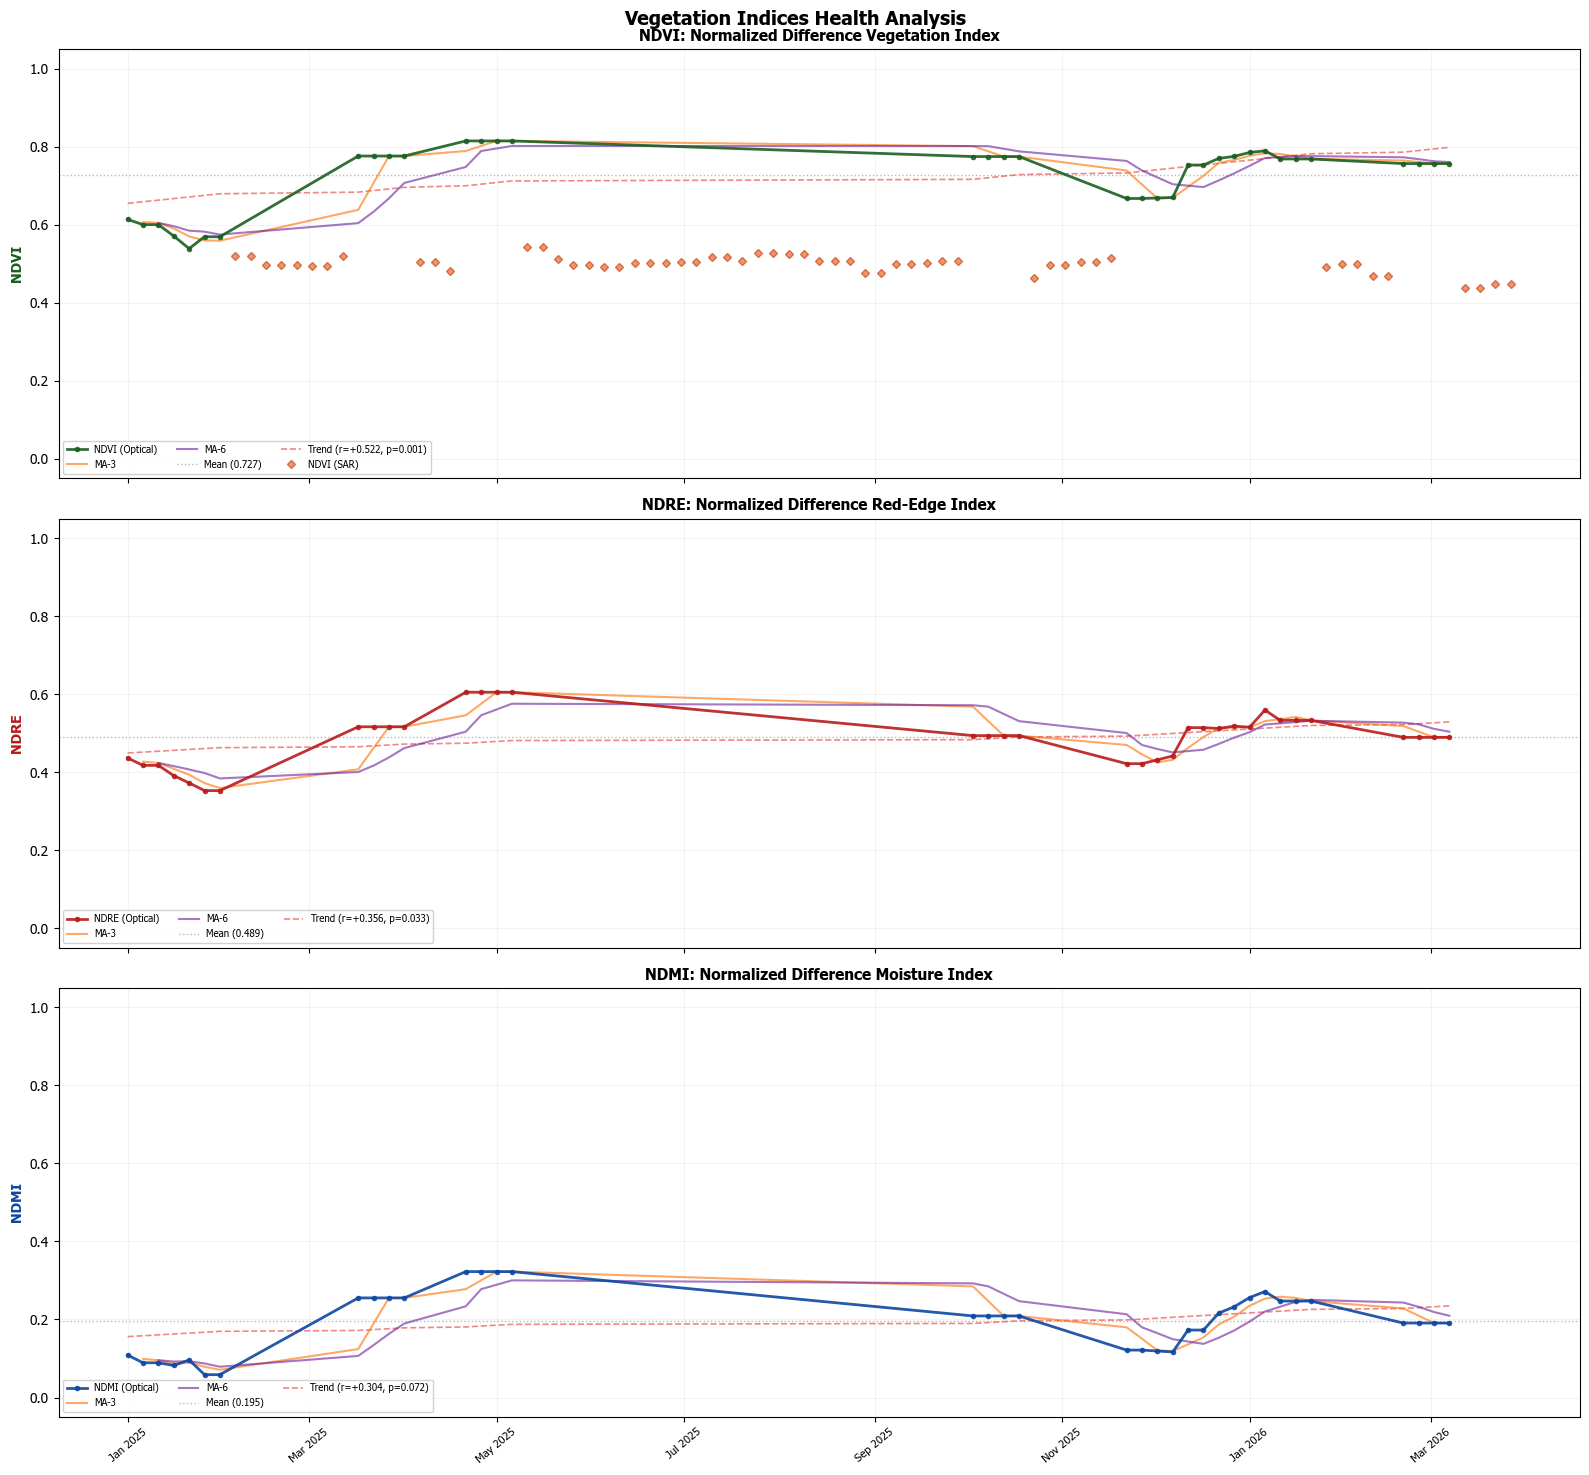

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 6. INDIVIDUAL INDEX ANALYSIS (NDVI / NDRE / NDMI)
# ══════════════════════════════════════════════════════════════════════

def plot_multi_index_health(df, baseline):
    indices = []
    for idx_name, color, full_name in [('NDVI','#1B5E20','Normalized Difference Vegetation Index'),
                                        ('NDRE','#B71C1C','Normalized Difference Red-Edge Index'),
                                        ('NDMI','#0D47A1','Normalized Difference Moisture Index')]:
        if idx_name in df.columns and df[idx_name].notna().sum() >= 3:
            indices.append((idx_name, color, full_name))
    
    if not indices:
        print('  ⚠ ไม่มีข้อมูลดัชนีเพียงพอ')
        return
    
    fig, axes = plt.subplots(len(indices), 1, figsize=(16, 5*len(indices)), sharex=True)
    fig.suptitle('Vegetation Indices Health Analysis', fontsize=14, fontweight='bold', y=0.98)
    
    if len(indices) == 1:
        axes = [axes]
    
    for ax, (idx_name, color, full_name) in zip(axes, indices):
        opt = df[df['is_optical'] & df[idx_name].notna()].copy()
        sar = df[df['is_sar'] & df[idx_name].notna()].copy()
        
        # Plot optical
        if len(opt) > 0:
            ax.plot(opt['Date'], opt[idx_name], 'o-', color=color, lw=2, ms=4,
                    mew=0, alpha=0.9, label=f'{idx_name} (Optical)', zorder=10)
            
            # Moving averages
            vals = opt[idx_name].values
            if len(vals) >= 3:
                ma3 = pd.Series(vals).rolling(3, min_periods=2).mean().values
                ax.plot(opt['Date'], ma3, '-', color='#FF6F00', lw=1.5, alpha=0.6,
                       label='MA-3', zorder=8)
            if len(vals) >= 6:
                ma6 = pd.Series(vals).rolling(6, min_periods=3).mean().values
                ax.plot(opt['Date'], ma6, '-', color='#6A1B9A', lw=1.5, alpha=0.6,
                       label='MA-6', zorder=8)
            
            # Mean line
            mean_val = np.nanmean(vals)
            ax.axhline(y=mean_val, color='#757575', ls=':', lw=1, alpha=0.5,
                      label=f'Mean ({mean_val:.3f})')
            
            # Linear trend
            x_num = np.arange(len(vals))
            slope, intercept, r, p_val, _ = sp_stats.linregress(x_num, vals)
            trend_line = slope * x_num + intercept
            ax.plot(opt['Date'], trend_line, '--', color='#E53935', lw=1.2, alpha=0.6,
                   label=f'Trend (r={r:+.3f}, p={p_val:.3f})')
        
        # SAR
        if len(sar) > 0:
            ax.plot(sar['Date'], sar[idx_name], 'D', color='#E65100', ms=4,
                    mew=1, mec='#BF360C', alpha=0.6, label=f'{idx_name} (SAR)', zorder=9)
        
        ax.set_ylabel(idx_name, fontsize=10, fontweight='bold', color=color)
        ax.set_title(f'{idx_name}: {full_name}', fontsize=11, fontweight='bold')
        ax.legend(loc='lower left', fontsize=7, ncol=3, framealpha=0.9)
        ax.grid(True, alpha=0.15)
        ax.set_ylim(-0.05, 1.05)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    axes[-1].tick_params(axis='x', labelsize=8, rotation=40)
    plt.tight_layout()
    plt.show()

plot_multi_index_health(df_analyzed, baseline)


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 7. HEALTH REPORT SUMMARY — สรุปผลการวิเคราะห์
# ══════════════════════════════════════════════════════════════════════

def print_final_report(df, baseline, trend_report):
    opt = df[df['is_optical'] & df['NDVI'].notna()]
    sar = df[df['is_sar'] & df['NDVI'].notna()]
    
    print('\n')
    print('╔' + '═'*70 + '╗')
    print('║' + ' BANANA PLANTATION HEALTH ANALYSIS REPORT '.center(70) + '║')
    print('║' + ' BananaAI v1.3.0 — สวนทวีทรัพย์ แปลง A3 '.center(70) + '║')
    print('╠' + '═'*70 + '╣')
    
    # 1. ข้อมูลที่วิเคราะห์
    print('║' + ' 1. ข้อมูลที่วิเคราะห์'.ljust(70) + '║')
    print('║' + f'    ช่วงเวลา: {df["Date"].min().strftime("%d/%m/%Y")} — {df["Date"].max().strftime("%d/%m/%Y")}'.ljust(70) + '║')
    print('║' + f'    จำนวน observations: {len(df)} (Optical: {len(opt)}, SAR: {len(sar)})'.ljust(70) + '║')
    
    if 'dqs' in df.columns:
        dqs_vals = df['dqs'].dropna()
        good_dqs = (dqs_vals >= 70).sum()
        print('║' + f'    DQS ≥ 70 (ดี): {good_dqs}/{len(dqs_vals)} ({good_dqs/len(dqs_vals)*100:.0f}%)'.ljust(70) + '║')
    
    print('║' + ' '.ljust(70) + '║')
    
    # 2. ผลวิเคราะห์ NDVI
    print('║' + ' 2. ผลวิเคราะห์ความสมบูรณ์ (NDVI)'.ljust(70) + '║')
    if len(opt) > 0:
        print('║' + f'    NDVI เฉลี่ย (Optical): {opt["NDVI"].mean():.3f} ± {opt["NDVI"].std():.3f}'.ljust(70) + '║')
        print('║' + f'    NDVI ต่ำสุด: {opt["NDVI"].min():.3f} | สูงสุด: {opt["NDVI"].max():.3f}'.ljust(70) + '║')
        print('║' + f'    NDVI ปัจจุบัน: {trend_report.get("current_ndvi",0):.3f}'.ljust(70) + '║')
    
    if 'NDRE' in df.columns:
        ndre_opt = df[df['is_optical'] & df['NDRE'].notna()]
        if len(ndre_opt) > 0:
            print('║' + f'    NDRE เฉลี่ย: {ndre_opt["NDRE"].mean():.3f} ± {ndre_opt["NDRE"].std():.3f}'.ljust(70) + '║')
    
    if 'NDMI' in df.columns:
        ndmi_opt = df[df['is_optical'] & df['NDMI'].notna()]
        if len(ndmi_opt) > 0:
            print('║' + f'    NDMI เฉลี่ย: {ndmi_opt["NDMI"].mean():.3f} ± {ndmi_opt["NDMI"].std():.3f}'.ljust(70) + '║')
    
    print('║' + ' '.ljust(70) + '║')
    
    # 3. แนวโน้ม
    print('║' + ' 3. แนวโน้มความสมบูรณ์'.ljust(70) + '║')
    trend_dir = 'เพิ่มขึ้น ↗' if trend_report.get('overall_slope',0) > 0.001 else 'ลดลง ↘' if trend_report.get('overall_slope',0) < -0.001 else 'คงที่ →'
    print('║' + f'    ทิศทาง: {trend_dir} ({trend_report.get("trend_per_month",0):+.4f}/เดือน)'.ljust(70) + '║')
    sig = 'มีนัยสำคัญ' if trend_report.get('overall_p',1) < 0.05 else 'ไม่มีนัยสำคัญ'
    print('║' + f'    นัยสำคัญทางสถิติ: {sig} (p={trend_report.get("overall_p",1):.4f})'.ljust(70) + '║')
    print('║' + f'    เทียบ Seasonal Baseline: {trend_report.get("vs_baseline",0):+.3f}'.ljust(70) + '║')
    print('║' + ' '.ljust(70) + '║')
    
    # 4. Anomaly
    print('║' + ' 4. ผลการตรวจจับความผิดปกติ'.ljust(70) + '║')
    if 'anomaly_type' in df.columns:
        counts = df['anomaly_type'].value_counts()
        for atype in ['critical','warning','watch','normal']:
            n = counts.get(atype, 0)
            icon = {'critical':'🔴','warning':'🟡','watch':'🟠','normal':'🟢'}.get(atype,'⚪')
            print('║' + f'    {icon} {atype.capitalize():12s}: {n:3d} observations'.ljust(70) + '║')
    print('║' + ' '.ljust(70) + '║')
    
    # 5. สถานะ
    print('║' + ' 5. สถานะและคำแนะนำ'.ljust(70) + '║')
    alert = trend_report.get('alert', 'N/A')
    alert_icon = trend_report.get('alert_icon', '⚪')
    print('║' + f'    {alert_icon} สถานะ: {alert}'.ljust(70) + '║')
    
    # คำแนะนำ
    if 'วิกฤต' in alert:
        advice = 'ควรตรวจสอบภาคสนามทันที ตรวจโรค/แมลง/น้ำท่วม'
    elif 'เฝ้าระวัง' in alert:
        advice = 'ควรตรวจสอบภาคสนามภายใน 1 สัปดาห์'
    elif 'สังเกตการณ์' in alert:
        advice = 'จับตาดูแนวโน้มในช่วง 2 สัปดาห์ข้างหน้า'
    else:
        advice = 'สุขภาพสวนอยู่ในเกณฑ์ปกติ ดำเนินการตามปกติ'
    
    print('║' + f'    💡 คำแนะนำ: {advice}'.ljust(70) + '║')
    print('║' + ' '.ljust(70) + '║')
    
    # 6. ข้อจำกัด
    print('║' + ' 6. ข้อจำกัดของการวิเคราะห์'.ljust(70) + '║')
    print('║' + '    • ค่า threshold เป็นค่าเบื้องต้น ยังไม่ validate กับ ground truth'.ljust(70) + '║')
    print('║' + '    • SAR NDVI มี bias สูง ผลวิเคราะห์ใช้เฉพาะ optical data'.ljust(70) + '║')
    print('║' + '    • ช่วงฝนข้อมูลอาจมี residual cloud contamination'.ljust(70) + '║')
    print('║' + '    • Weather-Adjusted model R² ต่ำ ควรเพิ่มข้อมูลมากขึ้น'.ljust(70) + '║')
    
    print('╚' + '═'*70 + '╝')
    print()

print_final_report(df_analyzed, baseline, trend_report)

print('\n' + '='*60)
print('  ✅ BananaAI v1.3.0 Health Analysis — เสร็จสมบูรณ์')
print('  📊 Graphs: 6 panels dashboard + 3 individual indices')
print('  📋 Reports: Seasonal Baseline + Anomaly + Trend + Summary')
print('='*60)




╔══════════════════════════════════════════════════════════════════════╗
║               BANANA PLANTATION HEALTH ANALYSIS REPORT               ║
║                BananaAI v1.3.0 — สวนทวีทรัพย์ แปลง A3                ║
╠══════════════════════════════════════════════════════════════════════╣
║ 1. ข้อมูลที่วิเคราะห์                                                ║
║    ช่วงเวลา: 01/01/2025 — 27/03/2026                                 ║
║    จำนวน observations: 91 (Optical: 36, SAR: 55)                     ║
║    DQS ≥ 70 (ดี): 32/91 (35%)                                        ║
║                                                                      ║
║ 2. ผลวิเคราะห์ความสมบูรณ์ (NDVI)                                     ║
║    NDVI เฉลี่ย (Optical): 0.727 ± 0.083                              ║
║    NDVI ต่ำสุด: 0.539 | สูงสุด: 0.815                                ║
║    NDVI ปัจจุบัน: 0.757                                              ║
║    NDRE เฉลี่ย: 0.489 ± 0.067                  